<div style="background-color:#EFF5FF; padding:22px; border-radius:10px; border-left:8px solid #0047AB;">
<h1 style="margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="margin-top:6px;">Notebook 2 — Clustering Modelling and Validation</h3>
</div>

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
<b>Workflow overview.</b> This notebook develops the segmentation as a sequence of modelling decisions rather than as a single KMeans run. Alternative feature spaces, scalers and clustering families are compared first; the final solution is then validated through silhouette analysis, hierarchical benchmarks, density-based checks, consensus stability and business profiling. The final labels are interpreted using the full customer profile, while the distance calculation is kept focused on the variables that best separate purchasing behaviour.
</div>


<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports and data loading</li>
<li>Candidate feature sets and scalers</li>
<li>Diagnostics A — scaler comparison, elbow and dendrograms</li>
<li>Diagnostics B — feature set &times; k silhouette grid</li>
<li><b>Model configuration</b> — feature set, scaler and number of clusters</li>
<li>Fit and validate (silhouette plot, PCA, UMAP)</li>
<li>Method benchmarks — hierarchical, DBSCAN, SOM, centroid-Ward</li>
<li>Ensemble / consensus robustness check</li>
<li>Segment profiling</li>
<li>Re-attach outliers and export</li>
</ol>
</div>


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>1) Imports and data loading</b></h2>
</div>

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

import utils_clustering as uc
from utils_cluster_characterization import CLUSTER_NAMES as cluster_names

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

In [2]:
DATA_DIR = Path.cwd().parent / "datasets"

regular = pd.read_csv(DATA_DIR / "info_clustering_unscaled.csv", index_col="customer_id")
outliers = pd.read_csv(DATA_DIR / "outlier_dataset.csv", index_col="customer_id")

print("Regular:", regular.shape, "| Outliers:", outliers.shape,
      "| Total:", len(regular) + len(outliers))
regular.head()

Regular: (32056, 26) | Outliers: (982, 26) | Total: 33038


,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,is_male,tenure,total_children,lifetime_spend_technology,log_total_spend
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,
3,1,1,1,3,11731.0,373.0,323.0,177.0,28.0,213.0,552.0,384.0,189,0.631599,1,38.794428,-9.215739,0.010342,-2.649291e-01,56.0,15,0,6,2,4809.0,9.830433
4,1,0,0,2,13694.0,2012.0,533.0,95.0,43.0,15.0,1880.0,665.0,130,0.149890,1,38.751711,-9.179611,0.193185,-8.810167e-01,50.0,15,0,13,1,1296.0,9.915120
5,0,0,0,2,12407.0,555.0,101.0,118.0,1265.0,273.0,507.0,222.0,81,0.069126,0,38.780678,-9.160656,0.258819,-9.659258e-01,54.0,17,1,21,0,101.0,9.651816
7,0,0,2,1,7493.0,84.0,757.0,1133.0,972.0,1083.0,485.0,184.0,92,0.253609,1,38.739548,-9.148679,-1.000000,-1.665335e-16,43.0,12,1,5,0,2761.0,9.612667
8,0,0,3,1,9187.0,380.0,592.0,718.0,1068.0,1015.0,297.0,441.0,6,0.186569,1,38.733071,-9.188188,-0.965926,-2.588190e-01,56.0,12,1,5,0,12099.0,10.158052


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>2) Candidate feature sets and scalers</b></h2>
<p style="margin:6px 0 0 0;">This section defines the modelling search space. The comparison separates absolute spend, transformed spend, promotion behaviour and optional demographic or engagement variables, so that the final feature set can be justified with evidence rather than selected manually.</p>
</div>


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
Why some columns repeat information: absolute <code>lifetime_spend_*</code> and <code>log_total_spend</code> both describe spend intensity; <code>tenure</code> = current year − <code>year_first_transaction</code>; <code>total_children</code> = <code>kids_home + teens_home</code>; <code>typical_hour</code> is replaced by its cyclic <code>sin/cos</code>. Avoid putting duplicated views of the same thing in one feature set. Identity/geo (<code>customer_id, latitude, longitude, is_male, customer_loyalty_flag</code>) are best left out of the distance and used for profiling.
</div>

In [3]:
candidate_sets = uc.build_candidate_feature_sets(regular)
for name, (cols, logabs) in candidate_sets.items():
    print(f'{name:32s} | {len(cols):2d} cols | log_abs_spend={logabs}')

scaler_options = ['Standard', 'MinMax', 'Robust', 'None']
print('\nScalers available:', scaler_options)

lifetime_spend                   |  9 cols | log_abs_spend=False
lifetime_spend no groceries      |  8 cols | log_abs_spend=False
log_lifetime_spend               |  9 cols | log_abs_spend=True
log_lifetime_spend no groceries  |  8 cols | log_abs_spend=True
spend + promo                    | 10 cols | log_abs_spend=False
spend + promo no groceries       |  9 cols | log_abs_spend=False
log_spend + promo                | 10 cols | log_abs_spend=True
log_spend + promo no groceries   |  9 cols | log_abs_spend=True
log_spend + demo                 | 12 cols | log_abs_spend=True
log_spend + demo no groceries    | 11 cols | log_abs_spend=True
log_spend + engagement + demo    | 18 cols | log_abs_spend=True
log_spend + engagement + demo no groceries | 17 cols | log_abs_spend=True

Scalers available: ['Standard', 'MinMax', 'Robust', 'None']


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>3) Diagnostics A — scaler comparison, elbow and dendrograms</b></h2>
<p style="margin:6px 0 0 0;">This block checks whether the selected structure depends strongly on preprocessing choices. Scaler comparison evaluates distance sensitivity, the elbow checks compactness gains, and the dendrograms inspect whether hierarchical structure is visible under several linkage rules.</p>
</div>


### 3.1 — Scaler comparison (silhouette vs k)

In [4]:
INSPECT_SET = "spend + promo no groceries"  
INSPECT_SCALER = "MinMax"  

inspect_cols, inspect_logabs = candidate_sets[INSPECT_SET]
print(f'Inspecting: {INSPECT_SET}  ({len(inspect_cols)} cols, log_abs={inspect_logabs})')
print(f'Inspection scaler: {INSPECT_SCALER}')


Inspecting: spend + promo no groceries  (9 cols, log_abs=False)
Inspection scaler: MinMax


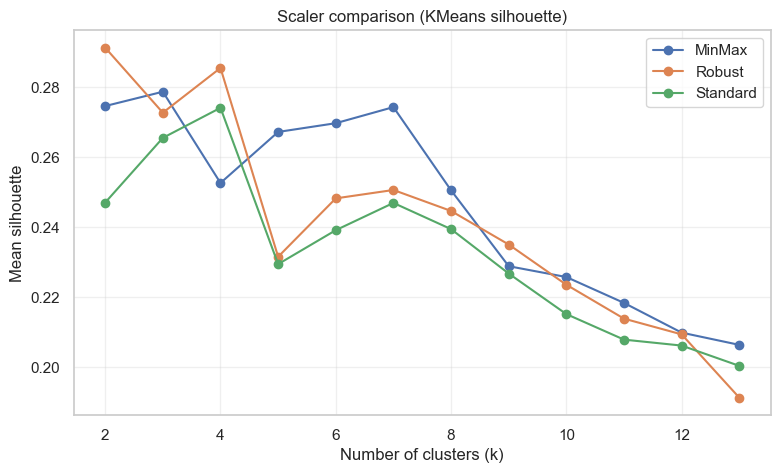

scaler,MinMax,Robust,Standard
k,,,
2,0.2746,0.2913,0.2470
3,0.2787,0.2727,0.2655
4,0.2526,0.2855,0.2741
5,0.2672,0.2315,0.2294
6,0.2697,0.2482,0.2391
7,0.2743,0.2506,0.2469
8,0.2505,0.2446,0.2394
9,0.2288,0.2350,0.2267
10,0.2257,0.2235,0.2151


In [5]:
scaler_scores = uc.compare_scalers(regular, inspect_cols, k_range=range(2, 14))
uc.plot_scaler_comparison(scaler_scores)
scaler_scores.pivot(index='k', columns='scaler', values='silhouette')

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
<b>Scaler selection interpretation.</b><br><br>
Both RobustScaler and MinMaxScaler were considered because the spend variables are skewed and measured on different scales. RobustScaler is usually safer when extreme observations remain in the modelling set, since it reduces the influence of unusually high values. However, in this project the most extreme customers are already held aside as outliers before fitting the final centroids. Under this cleaner modelling set, MinMaxScaler becomes a strong option because it places all clustering variables on the same 0-1 range while preserving their relative ordering.<br><br>
For the selected feature set and <i>k = 7</i>, MinMaxScaler produced a higher silhouette score than RobustScaler while preserving interpretable segment profiles. The resulting clusters still correspond to clear business groups. Therefore, MinMaxScaler is selected for the final model because it improves geometric separation without sacrificing interpretability.
</div>


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
<b>A note on groceries.</b> Groceries are kept in the dataset for profiling because they are behaviourally important. However, groceries can dominate the distance calculation because most customers spend heavily there. For this reason, the candidate grid includes versions with and without <code>lifetime_spend_groceries</code>. If the no-groceries option gives clearer personas, use it for KMeans and still use groceries afterwards to describe the segments.
</div>


### 3.2 — Inertia elbow

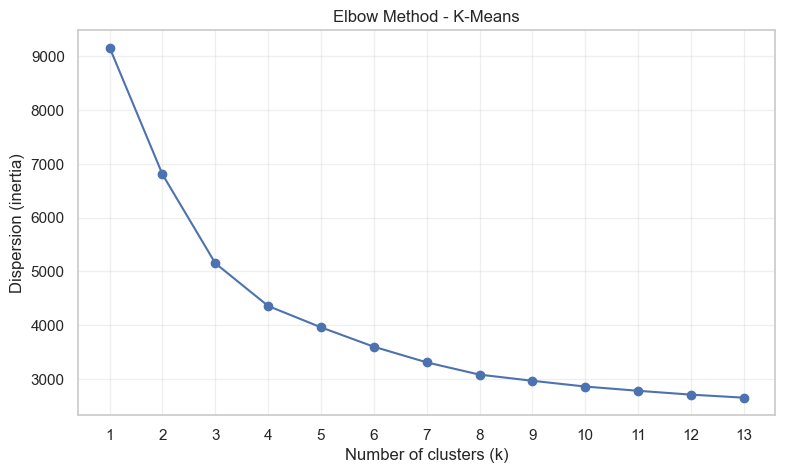

In [6]:
X_inspect = uc.apply_feature_pipeline(regular, inspect_cols, inspect_logabs,
                                      uc.get_scaler(INSPECT_SCALER), fit=True)
k_values, inertia = uc.kmeans_elbow(X_inspect, range(1, 14))
uc.plot_elbow(k_values, inertia)

### 3.3 — Ward dendrogram (on a sample)

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
Agglomerative clustering is O(n²) in memory, so we draw the dendrogram on a random sample. Reading where long vertical links get cut suggests candidate values of k.
</div>

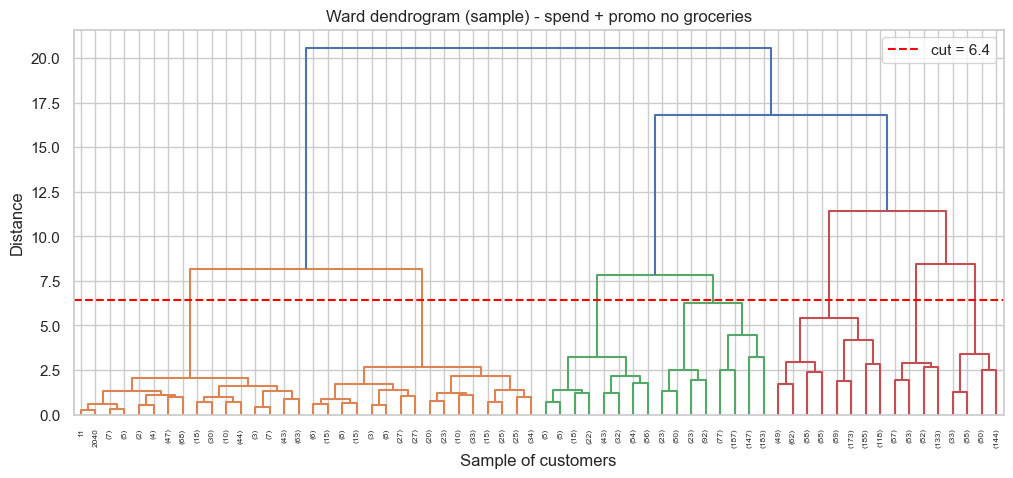

In [7]:
DENDRO_CUT_HEIGHT = 6.4 

_, dendro_model = uc.fit_dendrogram_model(X_inspect, sample_size=3000, linkage="ward")
fig, ax = plt.subplots(figsize=(12, 5))
plt.title(f"Ward dendrogram (sample) - {INSPECT_SET}")
uc.plot_dendrogram(dendro_model, truncate_mode="level", p=5)
if DENDRO_CUT_HEIGHT is not None:
    plt.axhline(y=DENDRO_CUT_HEIGHT, color="red", linestyle="--", linewidth=1.5,
                label=f"cut = {DENDRO_CUT_HEIGHT}")
    plt.legend(loc="upper right")
plt.xlabel("Sample of customers")
plt.ylabel("Distance")
plt.show()


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
<b>Ward dendrogram interpretation.</b><br><br>
The Ward dendrogram is used as a visual diagnostic for compact, variance-minimising group structure. Long vertical jumps indicate that relatively distant groups are being merged, so possible cut-points should be considered just before those large jumps. In this dataset, the dendrogram suggests that there is meaningful hierarchical structure, but it does not provide a single unambiguous cut. Several values of <i>k</i> remain plausible, which is why the final number of clusters is not chosen from the dendrogram alone.<br><br>
Ward is nevertheless useful because it is conceptually aligned with KMeans: both favour compact groups under Euclidean geometry. Therefore, if Ward shows a broadly coherent structure, it supports the use of a centroid-based final model.
</div>


### 3.4 — Complete, average and single linkage dendrograms

Ward is usually the most compatible linkage with KMeans because both favour compact groups. Complete, average and single linkage are added as sensitivity checks: complete tends to form tighter clusters, average provides an intermediate linkage criterion, and single can reveal chaining/noise effects.


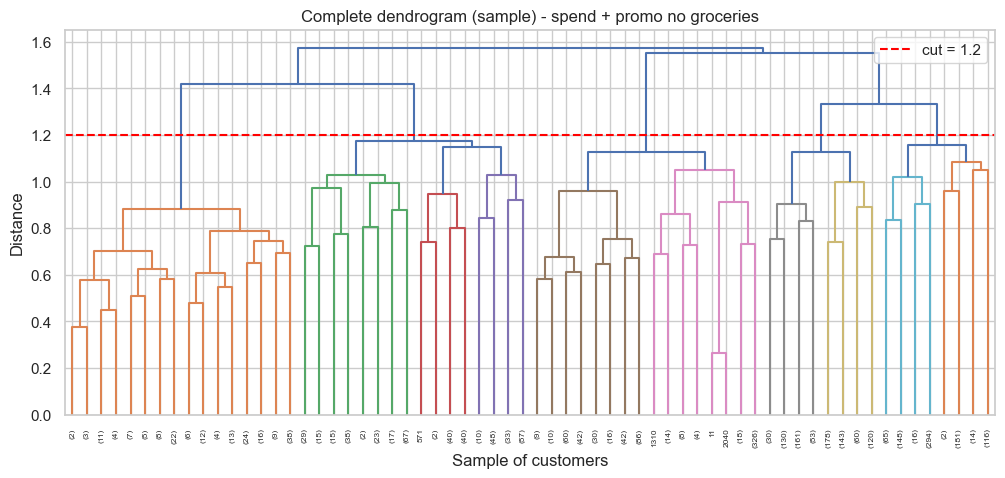

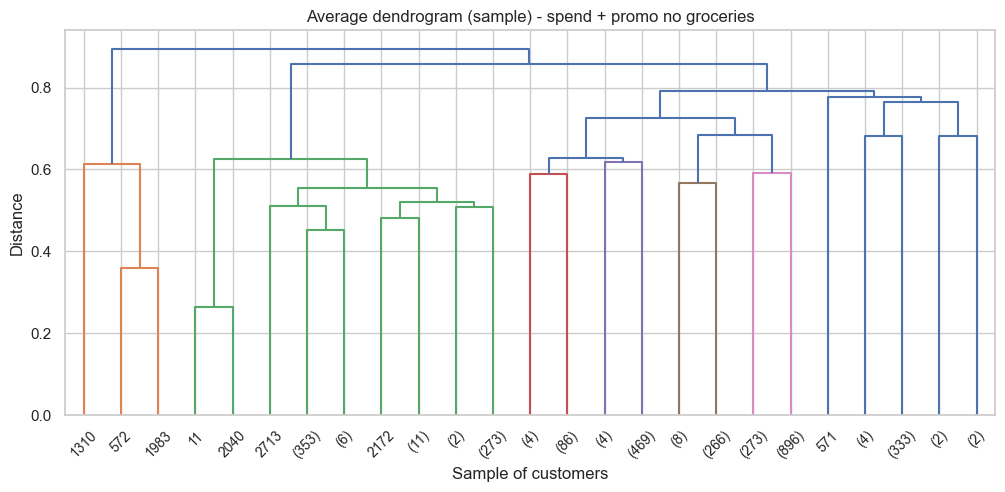

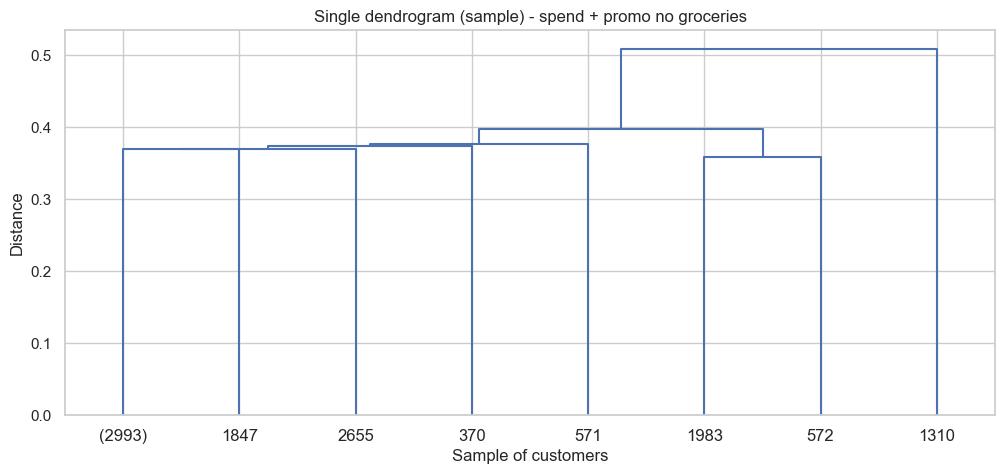

In [8]:
ALT_DENDRO_CUT_HEIGHTS = {
    "complete": 1.2,
    "average": None,
    "single": None,
}

for linkage_name in ["complete", "average", "single"]:
    _, dendro_model_alt = uc.fit_dendrogram_model(
        X_inspect,
        sample_size=3000,
        linkage=linkage_name,
        random_state=0,
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    plt.title(f"{linkage_name.title()} dendrogram (sample) - {INSPECT_SET}")
    uc.plot_dendrogram(dendro_model_alt, truncate_mode="level", p=5)

    cut_height = ALT_DENDRO_CUT_HEIGHTS.get(linkage_name)
    if cut_height is not None:
        plt.axhline(y=cut_height, color="red", linestyle="--", linewidth=1.5,
                    label=f"cut = {cut_height}")
        plt.legend(loc="upper right")

    plt.xlabel("Sample of customers")
    plt.ylabel("Distance")
    plt.show()


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
<b>Linkage comparison interpretation.</b><br><br>
The complete, average and single dendrograms are interpreted as sensitivity checks rather than competing final models.
<br><br>
<b>Complete linkage</b> tends to form compact and conservative clusters because it merges groups according to their farthest pairwise distance. If complete linkage shows large jumps, it suggests that some compact groups are clearly separated from the rest of the data.
<br><br>
<b>Average linkage</b> is less strict and merges clusters based on average distances between observations. It is useful as an intermediate check: when average linkage broadly agrees with Ward or complete linkage, the hierarchical structure is less dependent on one specific linkage rule.
<br><br>
<b>Single linkage</b> is the most sensitive to chaining effects, because clusters can be joined through narrow bridges of similar observations. If single linkage produces elongated chains or less clear cuts, this does not necessarily invalidate the segmentation; it indicates that some customers lie on behavioural gradients rather than in perfectly isolated groups.
<br><br>
Overall, the dendrograms support the idea that the data contains structure, but the cut-point remains partly subjective. For this reason, the final solution is selected using the dendrograms together with silhouette, scaler comparison, ensemble stability and profiling interpretability.
</div>


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>4) Diagnostics B — feature set × k silhouette grid</b></h2>
<p style="margin:6px 0 0 0;">After selecting the scaler and inspecting hierarchical structure, the silhouette grid is used to compare candidate feature spaces across several values of <i>k</i>. This provides a broader check that the final configuration is not chosen from a single diagnostic only.</p>
</div>


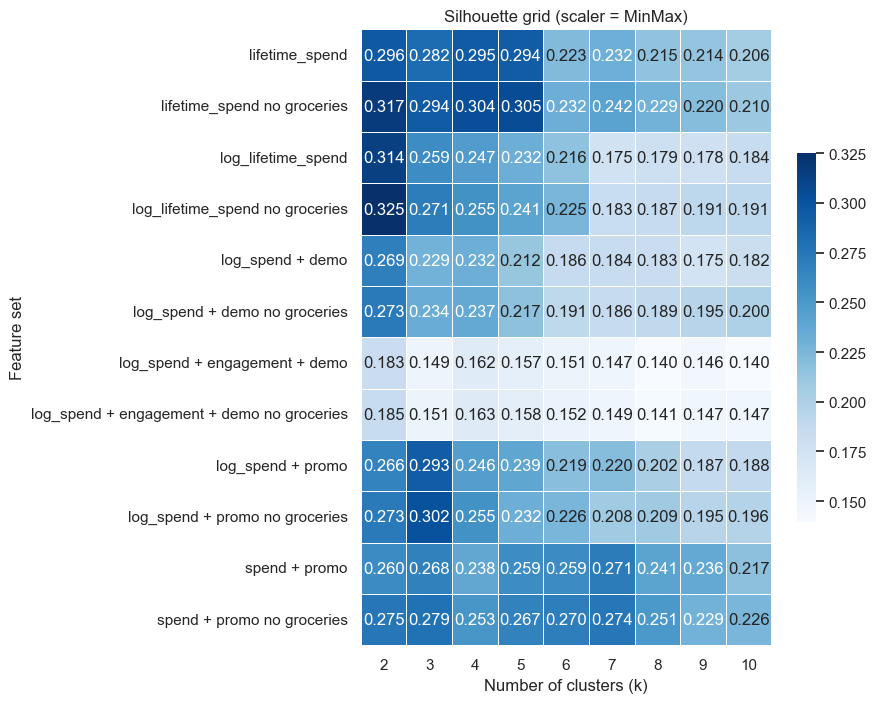

k,2,3,4,5,6,7,8,9,10
feature_set,,,,,,,,,
lifetime_spend,0.2958,0.2820,0.2948,0.2937,0.2228,0.2316,0.2154,0.2140,0.2059
lifetime_spend no groceries,0.3170,0.2944,0.3042,0.3051,0.2323,0.2419,0.2288,0.2196,0.2102
log_lifetime_spend,0.3141,0.2586,0.2474,0.2318,0.2160,0.1754,0.1787,0.1781,0.1838
log_lifetime_spend no groceries,0.3253,0.2707,0.2553,0.2409,0.2253,0.1834,0.1866,0.1913,0.1912
log_spend + demo,0.2687,0.2293,0.2320,0.2123,0.1862,0.1841,0.1830,0.1748,0.1818
log_spend + demo no groceries,0.2725,0.2335,0.2366,0.2168,0.1907,0.1860,0.1894,0.1950,0.2002
log_spend + engagement + demo,0.1830,0.1494,0.1619,0.1566,0.1507,0.1475,0.1395,0.1458,0.1398
log_spend + engagement + demo no groceries,0.1846,0.1507,0.1630,0.1579,0.1517,0.1489,0.1412,0.1468,0.1467
log_spend + promo,0.2662,0.2935,0.2457,0.2394,0.2190,0.2195,0.2022,0.1872,0.1883


In [9]:
grid = uc.silhouette_grid(regular, candidate_sets, k_range=range(2, 11),
                          scaler_name='MinMax')
grid_pivot = uc.plot_silhouette_grid(grid, title='Silhouette grid (scaler = MinMax)')
grid_pivot

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
<b>Interpretation.</b> Higher silhouette values indicate more compact and separated clusters for each candidate feature space. However, model selection also considers scaler behaviour, dendrogram structure, cluster-size balance and business interpretability, since a mathematically strong solution is not necessarily the most useful segmentation.
</div>

<div style="background-color:#FFF6E5; padding:20px; border-radius:10px; border-left:8px solid #E08600;">
<h2 style="margin:0;"><b>5) Model configuration</b></h2>
<p style="margin:6px 0 0 0;">The final configuration is chosen after the diagnostic stage. The objective is not to maximise one metric in isolation, but to select a solution that is quantitatively acceptable, stable and interpretable from a customer-segmentation perspective.</p>
</div>


In [10]:
FEATURE_SET = "spend + promo no groceries"    
SCALER      = "MinMax"  
K           = 7  

In [11]:
distance_cols, LOGABS = candidate_sets[FEATURE_SET]
profiling_cols = uc.get_profiling_features(regular, distance_cols)
scaler = uc.get_scaler(SCALER)
X = uc.apply_feature_pipeline(regular, distance_cols, LOGABS, scaler, fit=True)

print(f'Feature set : {FEATURE_SET}  ({len(distance_cols)} cols, log_abs={LOGABS})')
print(f'Scaler      : {SCALER}')
print(f'k           : {K}')
print(f'Matrix      : {X.shape}')

Feature set : spend + promo no groceries  (9 cols, log_abs=False)
Scaler      : MinMax
k           : 7
Matrix      : (32056, 9)


<div style="background-color:#FFF6E5; padding:16px; border-radius:10px; border-left:8px solid #E08600;">
<b>Decision log.</b><br><br>
Chosen feature set: <i>spend + promo no groceries</i><br>
Chosen scaler: <i>MinMaxScaler</i><br>
Chosen number of clusters: <i>k = 7</i><br>
Final model: <i>KMeans, followed by consensus-stability validation</i><br><br>
Justification:<br>
The selected feature set keeps the main purchasing categories and promotion behaviour in the clustering distance, while excluding groceries from the distance because groceries dominate most customer baskets and can make several segments look too similar. Groceries are still retained for profiling, where they remain important for interpretation.<br><br>
MinMax scaling is selected because the final modelling set is already cleaned of the most extreme outliers, making a bounded 0-1 transformation appropriate for comparing spend categories and promotion behaviour. In the scaler comparison, MinMax produced a higher silhouette score than Robust for the selected feature set and <i>k = 7</i>, while keeping the segment profiles interpretable.<br><br>
The final value of <i>k = 7</i> is selected as a compromise between statistical validation and business interpretability. The silhouette score indicates moderate separation, which is expected in behavioural customer data, while the consensus analysis confirms that the solution remains stable across KMeans initialisations. The accepted trade-off is therefore moderate geometric separation in exchange for stable and interpretable customer segments.
</div>


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>6) Model fitting and validation</b></h2>
<p style="margin:6px 0 0 0;">K-Means is fitted using the selected configuration. The solution is then validated through cluster-size distribution, silhouette analysis and two-dimensional PCA/UMAP projections.</p>
</div>

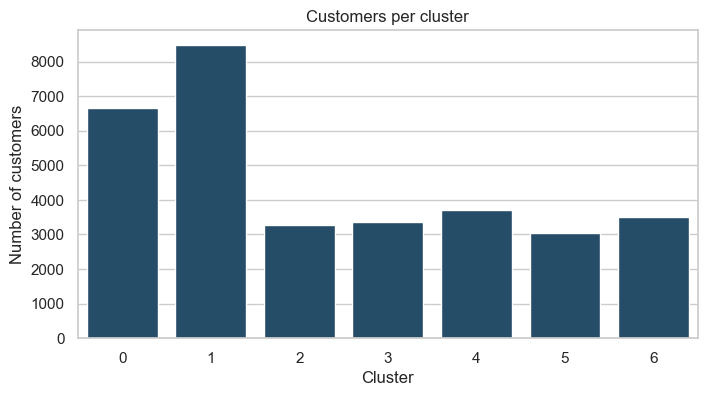

,customers,share_%
cluster,,
0,6648,20.7
1,8481,26.5
2,3273,10.2
3,3374,10.5
4,3714,11.6
5,3046,9.5
6,3520,11.0


In [12]:
kmeans = uc.fit_kmeans(X, K)
regular['cluster'] = kmeans.labels_
uc.plot_cluster_sizes(regular, 'cluster')
uc.cluster_sizes(regular, 'cluster')

### 6.1 — Silhouette plot

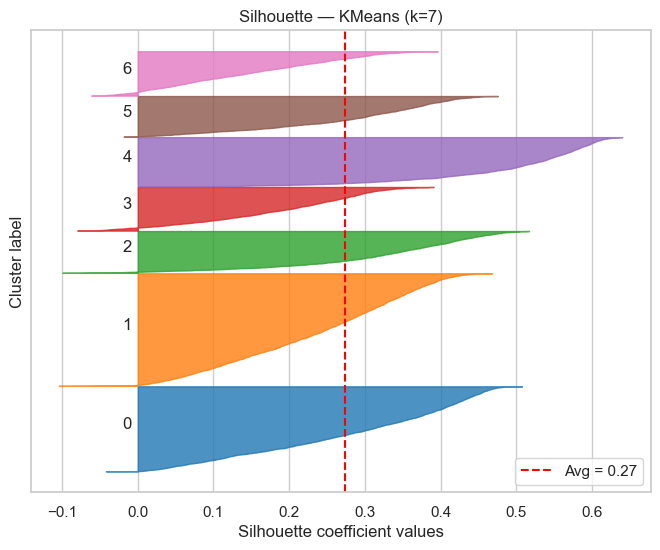

Average silhouette: 0.273


In [13]:
avg_sil = uc.plot_silhouette_blades(X, kmeans.labels_, title=f'Silhouette — KMeans (k={K})')
print('Average silhouette:', round(avg_sil, 3))

### 6.2 — PCA and UMAP projections

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
PCA and UMAP are used as two-dimensional projections for visual inspection. A subsample is used to keep the visualisation computationally efficient.
</div>

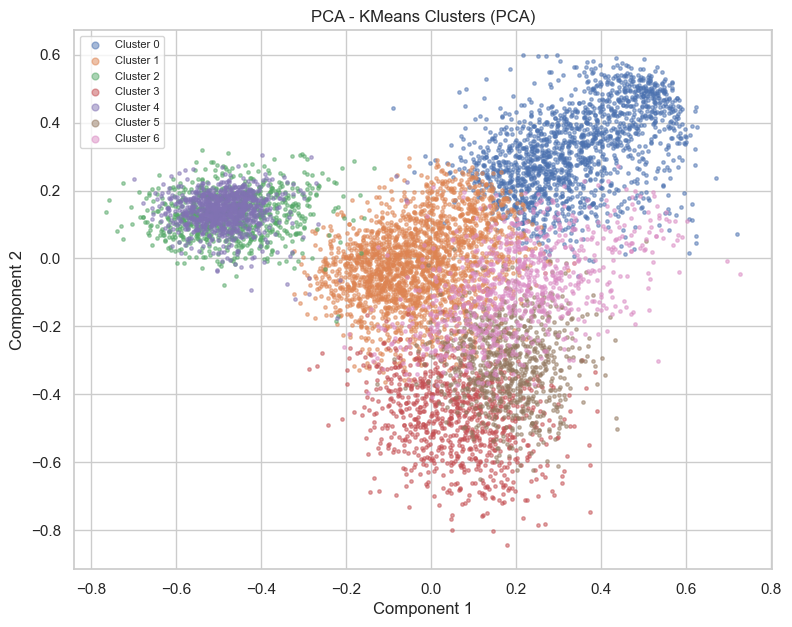

In [14]:
X_emb, lab_emb = uc.subsample(X, kmeans.labels_, n=8000)
pca_emb = uc.embed_pca(X_emb)
uc.plot_embedding(pca_emb, lab_emb, title='PCA - KMeans Clusters', method_name='PCA')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


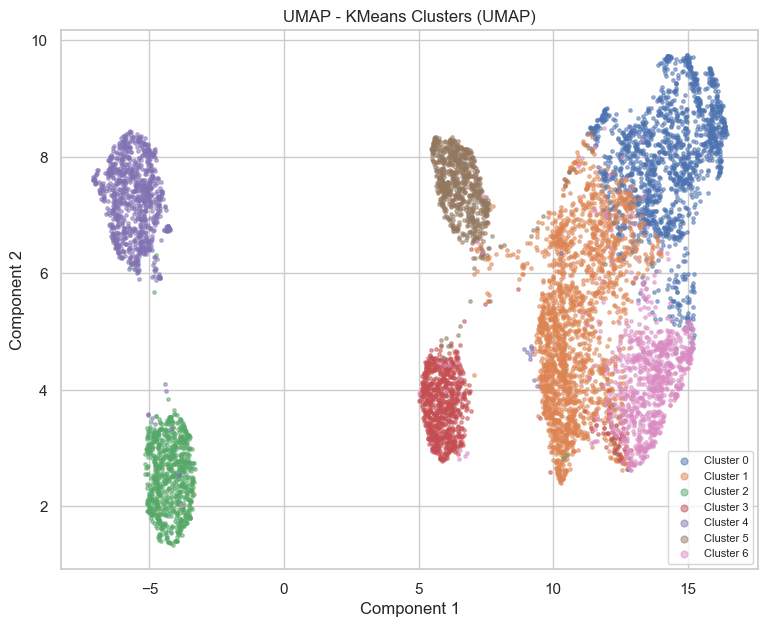

In [15]:
umap_emb, method = uc.embed_umap(X_emb)
uc.plot_embedding(umap_emb, lab_emb, title='UMAP - KMeans Clusters', method_name=method)

### 6.3 — Embedded feature-importance check (validates the feature set)

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
The correlation matrix in Notebook&nbsp;1 is a <b>filter</b> method: it only removes <i>redundant</i> features and cannot say which features actually <i>drive</i> the segments. Here we add an <b>embedded</b> method &mdash; an L1-penalised (Lasso) logistic model and a Random Forest &mdash; using the cluster label as a pseudo-target. The L1 penalty shrinks uninformative coefficients to exactly zero (an embedded selection), and both models rank how much each feature contributes to telling the segments apart. A peaked, sparse ranking means the segmentation rests on a few interpretable drivers. This is a post-hoc validation of the feature set chosen in Section&nbsp;5, not a pre-selection step.
</div>

,lasso_importance,lasso_selected,forest_importance
feature,,,
percentage_of_products_bought_promotion,0.1692,True,0.2437
lifetime_spend_hygiene,0.1292,True,0.1355
lifetime_spend_vegetables,0.1188,True,0.1197
lifetime_spend_fish,0.1147,True,0.0662
lifetime_spend_meat,0.1102,True,0.1112
lifetime_spend_alcohol_drinks,0.1091,True,0.0763
lifetime_spend_nonalcohol_drinks,0.1080,True,0.0897
lifetime_spend_technology,0.1024,True,0.1433
lifetime_spend_petfood,0.0384,True,0.0143


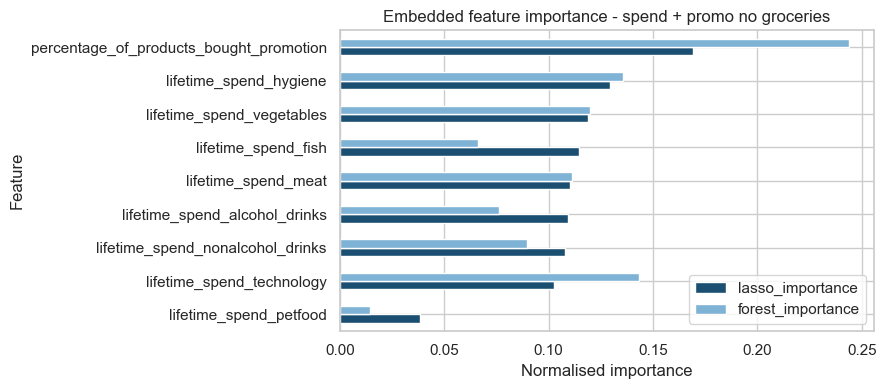

Embedded shortlist (forest importance > median): ['percentage_of_products_bought_promotion', 'lifetime_spend_hygiene', 'lifetime_spend_vegetables', 'lifetime_spend_technology']


In [16]:
emb_importance = uc.embedded_feature_importance(
    X, kmeans.labels_, distance_cols, method='both', random_state=0
)
display(emb_importance)
uc.plot_embedded_importance(emb_importance,
                            title=f'Embedded feature importance - {FEATURE_SET}')

print('Embedded shortlist (forest importance > median):',
      uc.select_features_embedded(emb_importance, 'forest_importance'))

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>7) Method benchmarks before ensemble</b></h2>
<p style="margin:6px 0 0 0;">The selected KMeans model is compared with alternative clustering assumptions before the ensemble step. These benchmarks are sensitivity checks: they show whether similar customer structure appears under hierarchical and density-based methods, and whether the chosen number of clusters remains plausible.</p>
</div>


### 7.0 — Independent method search

Before forcing all methods to use the final value of `K`, each clustering family is evaluated on its own candidate range. This avoids assuming from the start that every algorithm should naturally produce seven clusters. The goal is to compare the preferred structures suggested by KMeans, hierarchical clustering, centroid-Ward and DBSCAN before selecting the final operational solution.


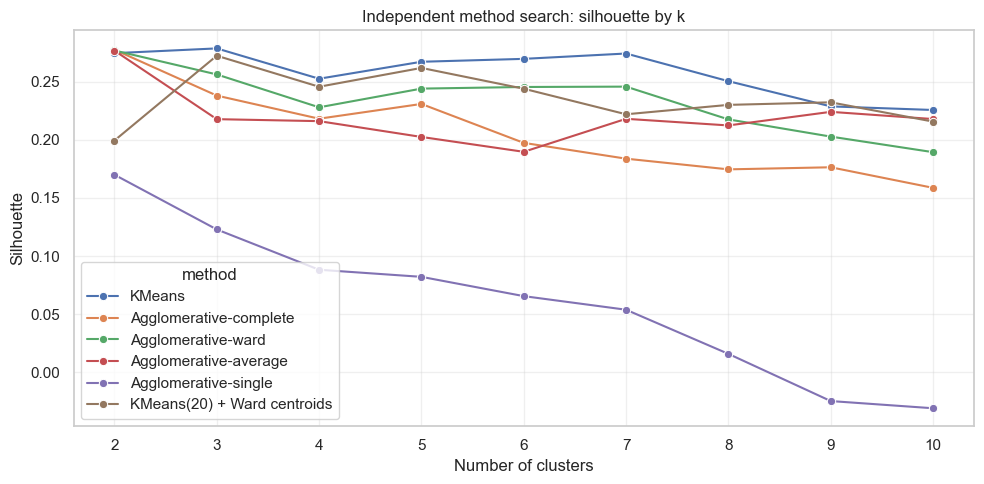

,method,k,silhouette,min_cluster_size,max_cluster_size,largest_share_%,linkage,sample_size,r2,micro_k
1,KMeans,3,0.2787,7185,15685,48.9,NaN,NaN,NaN,NaN
9,Agglomerative-complete,2,0.2776,1118,3882,77.6,complete,5000.0,0.2542,NaN
10,Agglomerative-ward,2,0.2769,1115,3885,77.7,ward,5000.0,0.2534,NaN
11,Agglomerative-average,2,0.2768,1118,3882,77.6,average,5000.0,0.2536,NaN
0,KMeans,2,0.2746,7346,24710,77.1,NaN,NaN,NaN,NaN
5,KMeans,7,0.2743,3046,8481,26.5,NaN,NaN,NaN,NaN
46,KMeans(20) + Ward centroids,3,0.2724,6950,16247,50.7,NaN,NaN,0.4309,20.0
4,KMeans,6,0.2697,3014,8915,27.8,NaN,NaN,NaN,NaN
3,KMeans,5,0.2672,3015,8964,28.0,NaN,NaN,NaN,NaN
48,KMeans(20) + Ward centroids,5,0.2619,2940,10183,31.8,NaN,NaN,0.5465,20.0


In [17]:
K_SEARCH_RANGE = range(2, 11)

kmeans_search = uc.kmeans_k_benchmark(
    X,
    k_range=K_SEARCH_RANGE,
    random_state=0,
    n_init=10,
    sample_size=8000,
)

hierarchical_search = uc.hierarchical_k_benchmark(
    X,
    k_range=K_SEARCH_RANGE,
    linkages=["ward", "complete", "average", "single"],
    sample_size=5000,
    random_state=0,
)

centroid_ward_search = uc.centroid_ward_k_benchmark(
    X,
    macro_k_range=K_SEARCH_RANGE,
    micro_k=20,
    random_state=0,
    n_init=20,
    sample_size=8000,
)

method_k_results = pd.concat(
    [kmeans_search, hierarchical_search, centroid_ward_search],
    ignore_index=True,
    sort=False,
)

uc.plot_method_k_benchmark(
    method_k_results,
    title="Independent method search: silhouette by k",
)

display(
    method_k_results
    .sort_values(["silhouette", "r2"], ascending=[False, False], na_position="last")
    .head(20)
)


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
<b>How this table is used.</b><br><br>
The top-ranked solution in this diagnostic is not automatically selected as the final model. Some methods may achieve a higher silhouette by creating very broad or very uneven clusters, while others may produce structures that are hard to name. The final choice is based on four criteria together: separation, stability, cluster-size balance and profiling interpretability.
<br><br>
This search is therefore used to document the alternatives. If a method suggests a different number of clusters, that result is discussed as evidence. The final `K` is retained only if it remains competitive and produces clearer business segments than the alternatives.
</div>


In [18]:
sample_idx, ward_labels = uc.fit_hierarchical_sample(X, K, sample_size=5000, linkage='ward')
uc.compare_solutions(kmeans.labels_[sample_idx], ward_labels, name_a='KMeans', name_b='Ward')

,Ward 0,Ward 1,Ward 2,Ward 3,Ward 4,Ward 5,Ward 6
KMeans 0,912,1,54,3,0,0,0
KMeans 1,293,992,16,25,6,1,1
KMeans 2,0,6,0,0,0,12,504
KMeans 3,0,56,7,12,477,0,0
KMeans 4,1,2,0,0,0,586,9
KMeans 5,2,35,4,432,10,0,0
KMeans 6,46,126,360,3,4,0,2


### 7.1 — Ward vs complete vs average vs single sample comparison

This fits agglomerative clustering on the same sample with four linkages. It does not replace the final KMeans model; it checks whether the broad structure is stable under different hierarchical assumptions.


In [19]:
hierarchical_rows = []
hierarchical_sample_labels = {}

for linkage_name in ["ward", "complete", "average", "single"]:
    sample_idx_l, labels_l = uc.fit_hierarchical_sample(
        X, K, sample_size=5000, linkage=linkage_name, random_state=0
    )
    hierarchical_sample_labels[linkage_name] = (sample_idx_l, labels_l)

    sil_l = silhouette_score(X[sample_idx_l], labels_l)
    hierarchical_rows.append({
        "method": f"Agglomerative-{linkage_name}",
        "sample_size": len(sample_idx_l),
        "k": K,
        "silhouette_sample": round(float(sil_l), 4),
    })

hierarchical_comparison = pd.DataFrame(hierarchical_rows)
display(hierarchical_comparison)

for linkage_name, (sample_idx_l, labels_l) in hierarchical_sample_labels.items():
    print(f"KMeans vs Agglomerative-{linkage_name}")
    display(uc.compare_solutions(
        kmeans.labels_[sample_idx_l],
        labels_l,
        name_a="KMeans",
        name_b=f"{linkage_name.title()}",
    ))


,method,sample_size,k,silhouette_sample
0,Agglomerative-ward,5000,7,0.2458
1,Agglomerative-complete,5000,7,0.1838
2,Agglomerative-average,5000,7,0.2181
3,Agglomerative-single,5000,7,0.0538


KMeans vs Agglomerative-ward


,Ward 0,Ward 1,Ward 2,Ward 3,Ward 4,Ward 5,Ward 6
KMeans 0,912,1,54,3,0,0,0
KMeans 1,293,992,16,25,6,1,1
KMeans 2,0,6,0,0,0,12,504
KMeans 3,0,56,7,12,477,0,0
KMeans 4,1,2,0,0,0,586,9
KMeans 5,2,35,4,432,10,0,0
KMeans 6,46,126,360,3,4,0,2


KMeans vs Agglomerative-complete


,Complete 0,Complete 1,Complete 2,Complete 3,Complete 4,Complete 5,Complete 6
KMeans 0,0,0,670,0,1,3,296
KMeans 1,24,4,10,917,6,25,348
KMeans 2,0,518,0,4,0,0,0
KMeans 3,477,0,0,66,9,0,0
KMeans 4,0,596,1,1,0,0,0
KMeans 5,7,0,0,51,408,1,16
KMeans 6,121,0,182,56,2,14,166


KMeans vs Agglomerative-average


,Average 0,Average 1,Average 2,Average 3,Average 4,Average 5,Average 6
KMeans 0,0,0,0,0,0,2,968
KMeans 1,1,976,0,7,5,0,345
KMeans 2,0,6,0,515,1,0,0
KMeans 3,3,57,2,0,489,0,1
KMeans 4,0,2,0,595,0,0,1
KMeans 5,0,467,0,0,8,1,7
KMeans 6,2,184,2,1,7,0,345


KMeans vs Agglomerative-single


,Single 0,Single 1,Single 2,Single 3,Single 4,Single 5,Single 6
KMeans 0,967,0,0,1,0,1,1
KMeans 1,1334,0,0,0,0,0,0
KMeans 2,522,0,0,0,0,0,0
KMeans 3,550,0,1,0,1,0,0
KMeans 4,598,0,0,0,0,0,0
KMeans 5,482,1,0,0,0,0,0
KMeans 6,541,0,0,0,0,0,0


### 7.1.1 — Tracking benchmark labels

Some clustering workflows store every attempted solution as a separate column, such as `st_ward5`, `mm_ward9` or `rb_kmeans6`. In this notebook, the same idea is applied more selectively. Full-data labels are stored when they are used later for profiling, export or comparison. Direct agglomerative labels are computed on a sample because full hierarchical clustering has quadratic memory cost and is used here as a benchmark rather than as the final assignment method.


In [20]:
label_tracking = pd.DataFrame([
    {
        "solution": "Final KMeans",
        "label_column": "cluster",
        "scope": "full regular dataset",
        "purpose": "final segment assignment before outlier reintegration",
    },
    {
        "solution": "Agglomerative linkages",
        "label_column": "hierarchical_sample_labels dictionary",
        "scope": "sample only",
        "purpose": "benchmark against KMeans under ward/complete/average/single linkage",
    },
    {
        "solution": "Centroid-Ward macro clusters",
        "label_column": "macro_cluster",
        "scope": "full regular dataset",
        "purpose": "two-stage hierarchical benchmark using 20 KMeans centroids",
    },
    {
        "solution": "DBSCAN",
        "label_column": "dbscan_cluster",
        "scope": "full regular dataset if RUN_DBSCAN=True",
        "purpose": "density-based benchmark and noise check",
    },
    {
        "solution": "SOM",
        "label_column": "som_unit",
        "scope": "full regular dataset",
        "purpose": "topology-based visual profiling, not final cluster assignment",
    },
])

display(label_tracking)


,solution,label_column,scope,purpose
0,Final KMeans,cluster,full regular dataset,final segment assignment before outlier reinte...
1,Agglomerative linkages,hierarchical_sample_labels dictionary,sample only,benchmark against KMeans under ward/complete/a...
2,Centroid-Ward macro clusters,macro_cluster,full regular dataset,two-stage hierarchical benchmark using 20 KMea...
3,DBSCAN,dbscan_cluster,full regular dataset if RUN_DBSCAN=True,density-based benchmark and noise check
4,SOM,som_unit,full regular dataset,"topology-based visual profiling, not final clu..."


### 7.2 — Hierarchical R2 comparison

The R2-like metric compares how much of the total variance is explained by the cluster separation for each hierarchical linkage and number of clusters. It is used as an additional diagnostic alongside silhouette and dendrogram inspection.


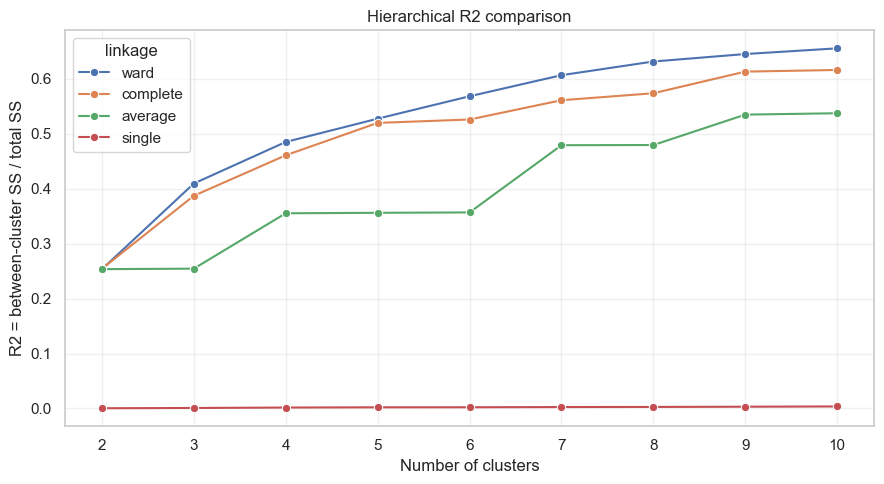

linkage,average,complete,single,ward
k,,,,
2,0.2536,0.2542,0.0003,0.2534
3,0.2545,0.3872,0.0008,0.4095
4,0.3553,0.4609,0.0016,0.4852
5,0.3562,0.5199,0.0020,0.5276
6,0.3569,0.5261,0.0021,0.5684
7,0.4793,0.5612,0.0025,0.6068
8,0.4796,0.5739,0.0027,0.6317
9,0.5350,0.6133,0.0031,0.6453
10,0.5375,0.6163,0.0036,0.6557


In [21]:
hierarchical_r2 = uc.hierarchical_r2_grid(
    X,
    k_range=range(2, 11),
    linkages=["ward", "complete", "average", "single"],
    sample_size=5000,
    random_state=0,
)

uc.plot_hierarchical_r2(hierarchical_r2)
display(hierarchical_r2.pivot(index="k", columns="linkage", values="r2"))


### 7.3 — Hierarchical on KMeans centroids
This benchmark uses a two-stage strategy. First, <b>20 KMeans micro-clusters</b> are created to summarise the detailed structure of the customer space. Second, Ward hierarchical clustering groups those centroids into the final macro-segments. Keeping <code>MICRO_K = 20</code> makes the intermediate representation granular enough to reveal local structure, while still small enough to inspect with a dendrogram.


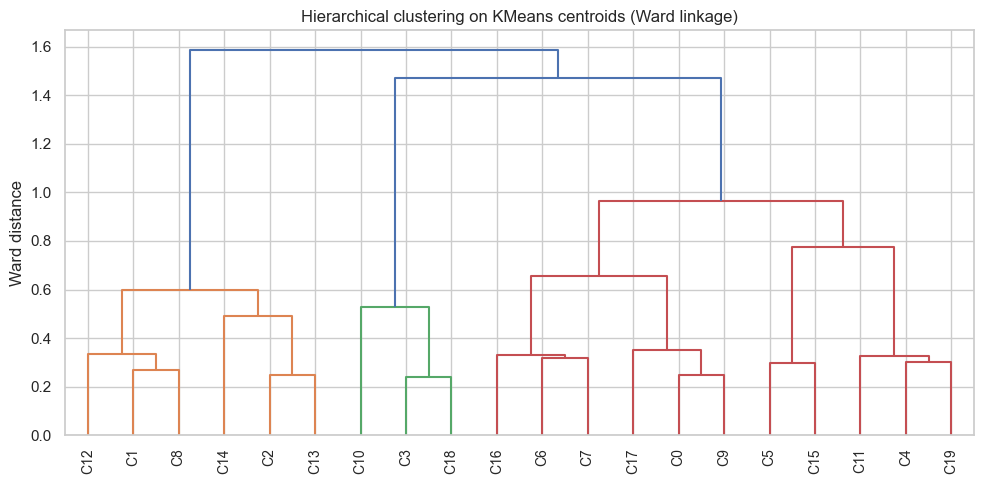

Micro-cluster sizes:


micro_cluster
0     2420
1     1850
2     1570
3     1706
4      898
5     1449
6     1324
7     1221
8     1759
9     2147
10    3651
11     984
12    1210
13    1547
14     923
15    1675
16    1298
17    1773
18    1593
19    1058
Name: count, dtype: int64

Macro-cluster sizes:


macro_cluster
0    4819
1    4040
2    6950
3    3843
4    6340
5    3124
6    2940
Name: count, dtype: int64

Macro-cluster silhouette: 0.2221
Final KMeans silhouette: 0.2733


In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

MICRO_K = 20
micro_kmeans = uc.fit_kmeans(X, MICRO_K, random_state=0, n_init=20)
regular["micro_cluster"] = micro_kmeans.labels_

centroids_df = pd.DataFrame(
    micro_kmeans.cluster_centers_,
    columns=distance_cols,
    index=[f"C{i}" for i in range(MICRO_K)],
)

Z = linkage(centroids_df.values, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(
    Z,
    labels=centroids_df.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
)
plt.title("Hierarchical clustering on KMeans centroids (Ward linkage)")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()

macro_labels_for_centroids = fcluster(Z, t=K, criterion="maxclust") - 1
centroid_to_macro = dict(zip(range(MICRO_K), macro_labels_for_centroids))
regular["macro_cluster"] = regular["micro_cluster"].map(centroid_to_macro)

print("Micro-cluster sizes:")
display(regular["micro_cluster"].value_counts().sort_index())

print("Macro-cluster sizes:")
display(regular["macro_cluster"].value_counts().sort_index())

macro_sil = silhouette_score(X, regular["macro_cluster"].values)
print(f"Macro-cluster silhouette: {macro_sil:.4f}")
print(f"Final KMeans silhouette: {avg_sil:.4f}")


,Centroid-Ward macro 0,Centroid-Ward macro 1,Centroid-Ward macro 2,Centroid-Ward macro 3,Centroid-Ward macro 4,Centroid-Ward macro 5,Centroid-Ward macro 6
Final KMeans 0,3197,3412,0,39,0,0,0
Final KMeans 1,1407,0,1,684,6274,113,2
Final KMeans 2,1,0,3254,11,7,0,0
Final KMeans 3,0,0,0,403,7,61,2903
Final KMeans 4,4,0,3695,0,14,0,1
Final KMeans 5,27,1,0,42,23,2939,14
Final KMeans 6,183,627,0,2664,15,11,20


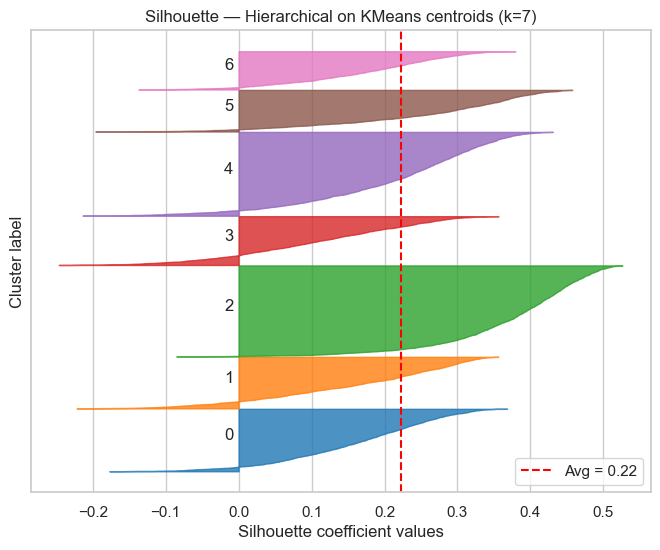

0.22203702734314612

In [23]:
macro_comparison = uc.compare_solutions(
    regular["cluster"].values,
    regular["macro_cluster"].values,
    name_a="Final KMeans",
    name_b="Centroid-Ward macro",
)
display(macro_comparison)

uc.plot_silhouette_blades(
    X,
    regular["macro_cluster"].values,
    title=f"Silhouette — Hierarchical on KMeans centroids (k={K})",
)


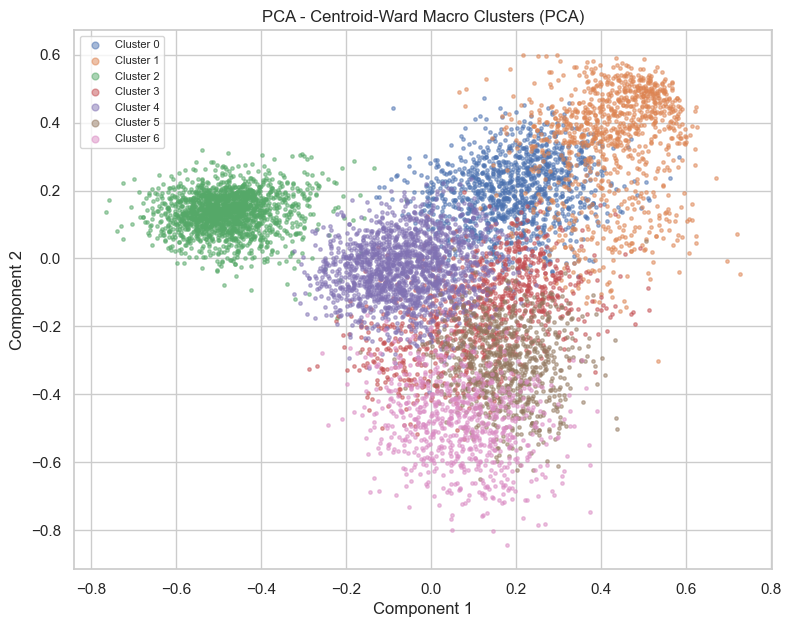

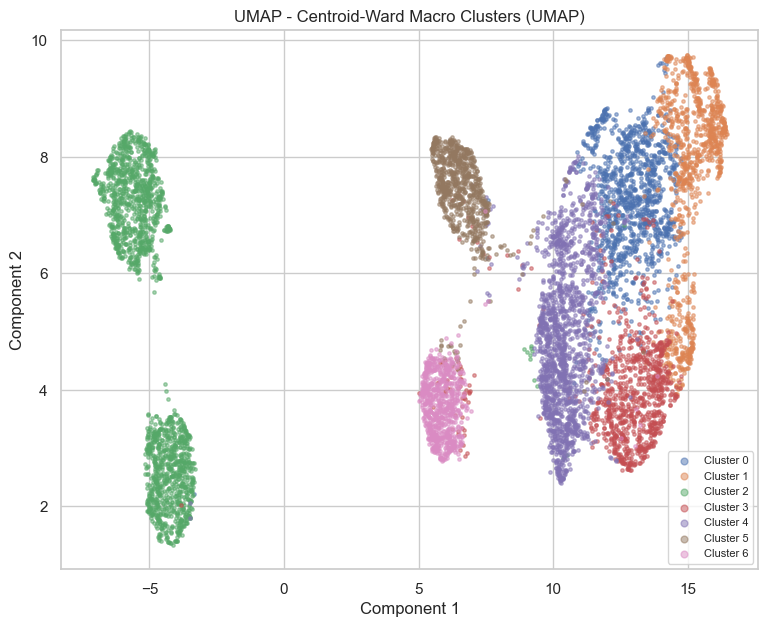

In [24]:
X_macro_emb, macro_lab_emb = uc.subsample(X, regular["macro_cluster"].values, n=8000)
macro_pca_emb = uc.embed_pca(X_macro_emb)
uc.plot_embedding(
    macro_pca_emb,
    macro_lab_emb,
    title="PCA - Centroid-Ward Macro Clusters",
    method_name="PCA",
)

macro_umap_emb, macro_method = uc.embed_umap(X_macro_emb)
uc.plot_embedding(
    macro_umap_emb,
    macro_lab_emb,
    title="UMAP - Centroid-Ward Macro Clusters",
    method_name=macro_method,
)


### 7.4 — DBSCAN density-based benchmark

DBSCAN is tested as a non-centroid benchmark. It can detect dense pockets and mark border/noise customers, but on high-dimensional customer-spend data it often produces either one large cluster or too much noise. We therefore use it as evidence, not as the default final segmentation.


In [25]:
dbscan_results = uc.dbscan_grid(
    X,
    eps_values=[0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 2.0],
    min_samples_values=[5, 10, 20, 40],
    sample_size=8000,
    random_state=0,
)
display(dbscan_results.head(20))


,eps,min_samples,n_clusters,noise_pct,silhouette_non_noise
0,0.5,5,1,0.0,NaN
1,0.5,10,1,0.0,NaN
2,0.5,20,1,0.0,NaN
3,0.5,40,1,0.0,NaN
4,0.7,5,1,0.0,NaN
5,0.7,10,1,0.0,NaN
6,0.7,20,1,0.0,NaN
7,0.7,40,1,0.0,NaN
8,0.9,5,1,0.0,NaN
9,0.9,10,1,0.0,NaN


In [26]:
RUN_DBSCAN = True
DBSCAN_EPS = 0.9
DBSCAN_MIN_SAMPLES = 10

if RUN_DBSCAN:
    if DBSCAN_EPS is None or DBSCAN_MIN_SAMPLES is None:
        raise ValueError("Define DBSCAN_EPS and DBSCAN_MIN_SAMPLES based on dbscan_results.")

    dbscan_labels = uc.fit_dbscan(X, eps=float(DBSCAN_EPS), min_samples=int(DBSCAN_MIN_SAMPLES))
    regular["dbscan_cluster"] = dbscan_labels

    print("Selected DBSCAN parameters:")
    print("eps:", DBSCAN_EPS, "| min_samples:", DBSCAN_MIN_SAMPLES)
    print("Clusters excluding noise:", len(set(dbscan_labels[dbscan_labels != -1])))
    print("Noise %:", round((dbscan_labels == -1).mean() * 100, 2))
    display(pd.Series(dbscan_labels).value_counts().sort_index())

    non_noise = dbscan_labels != -1
    if len(set(dbscan_labels[non_noise])) >= 2:
        print("DBSCAN silhouette without noise:",
              round(silhouette_score(X[non_noise], dbscan_labels[non_noise]), 4))
else:
    print("DBSCAN not selected. DBSCAN retained as a benchmark table unless RUN_DBSCAN is enabled.")


Selected DBSCAN parameters:
eps: 0.9 | min_samples: 10
Clusters excluding noise: 1
Noise %: 0.0


0    32056
Name: count, dtype: int64

### 7.5 — Self-Organising Map feature-map analysis

A Self-Organising Map is used as an exploratory validation tool rather than as the final clustering algorithm. A medium-sized grid is used so that neighbourhood patterns remain visible without creating hundreds of almost-empty units. The hit map shows where customers concentrate, the U-Matrix highlights stronger separations between neighbouring units, and the feature maps show how the main variables vary across the same customer space.

,iteration,quantization_error
0,50,0.3368
1,100,0.3460
2,200,0.3571
3,400,0.3472
4,700,0.3332
5,1000,0.3281


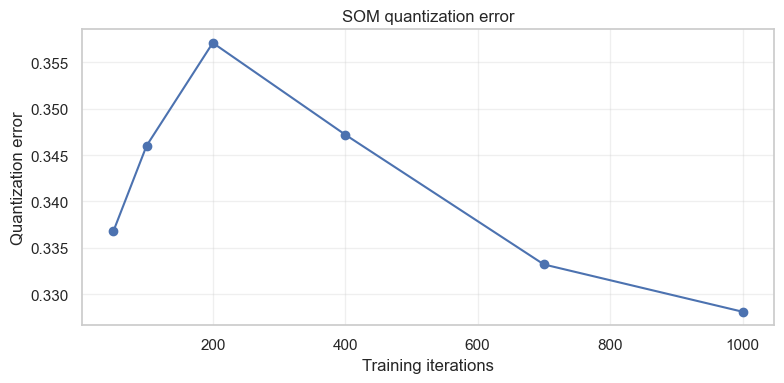

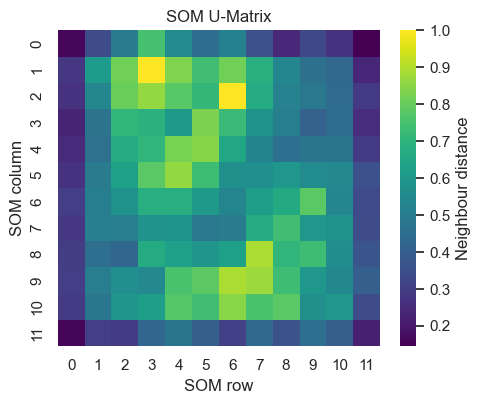

In [27]:
SOM_GRID = (12, 12)
SOM_ITERATIONS = 1000

som_cols = [c for c in [
    "lifetime_spend_groceries",
    "lifetime_spend_vegetables",
    "lifetime_spend_meat",
    "lifetime_spend_fish",
    "lifetime_spend_alcohol_drinks",
    "lifetime_spend_hygiene",
    "lifetime_spend_petfood",
    "lifetime_spend_technology",
    "percentage_of_products_bought_promotion",
    "total_children",
    "customer_age",
    "education_level",
    "number_complaints",
] if c in regular.columns]

som_scaler = uc.get_scaler(SCALER)
X_som = uc.apply_feature_pipeline(regular, som_cols, logabs=True, scaler=som_scaler, fit=True)

som_curve, som_model = uc.som_quantization_curve(
    X_som,
    grid=SOM_GRID,
    iterations=SOM_ITERATIONS,
    checkpoints=[50, 100, 200, 400, 700, 1000],
    sigma=1.2,
    learning_rate=0.5,
    sample_size=12000,
    random_state=0,
)

display(som_curve)
uc.plot_som_quantization_curve(som_curve)
uc.plot_som_umatrix(som_model, title="SOM U-Matrix")

Active SOM units: 144 out of 144


,customers
66,748
131,698
114,649
82,630
108,627
40,616
8,613
116,538
143,536
83,521


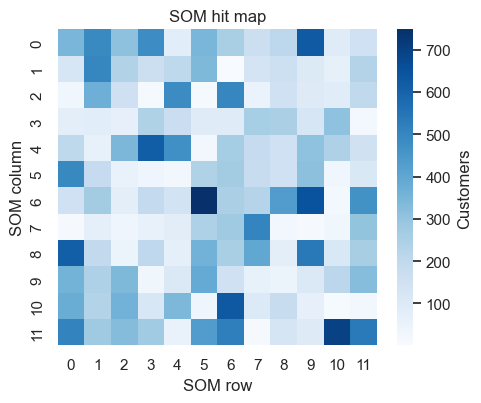

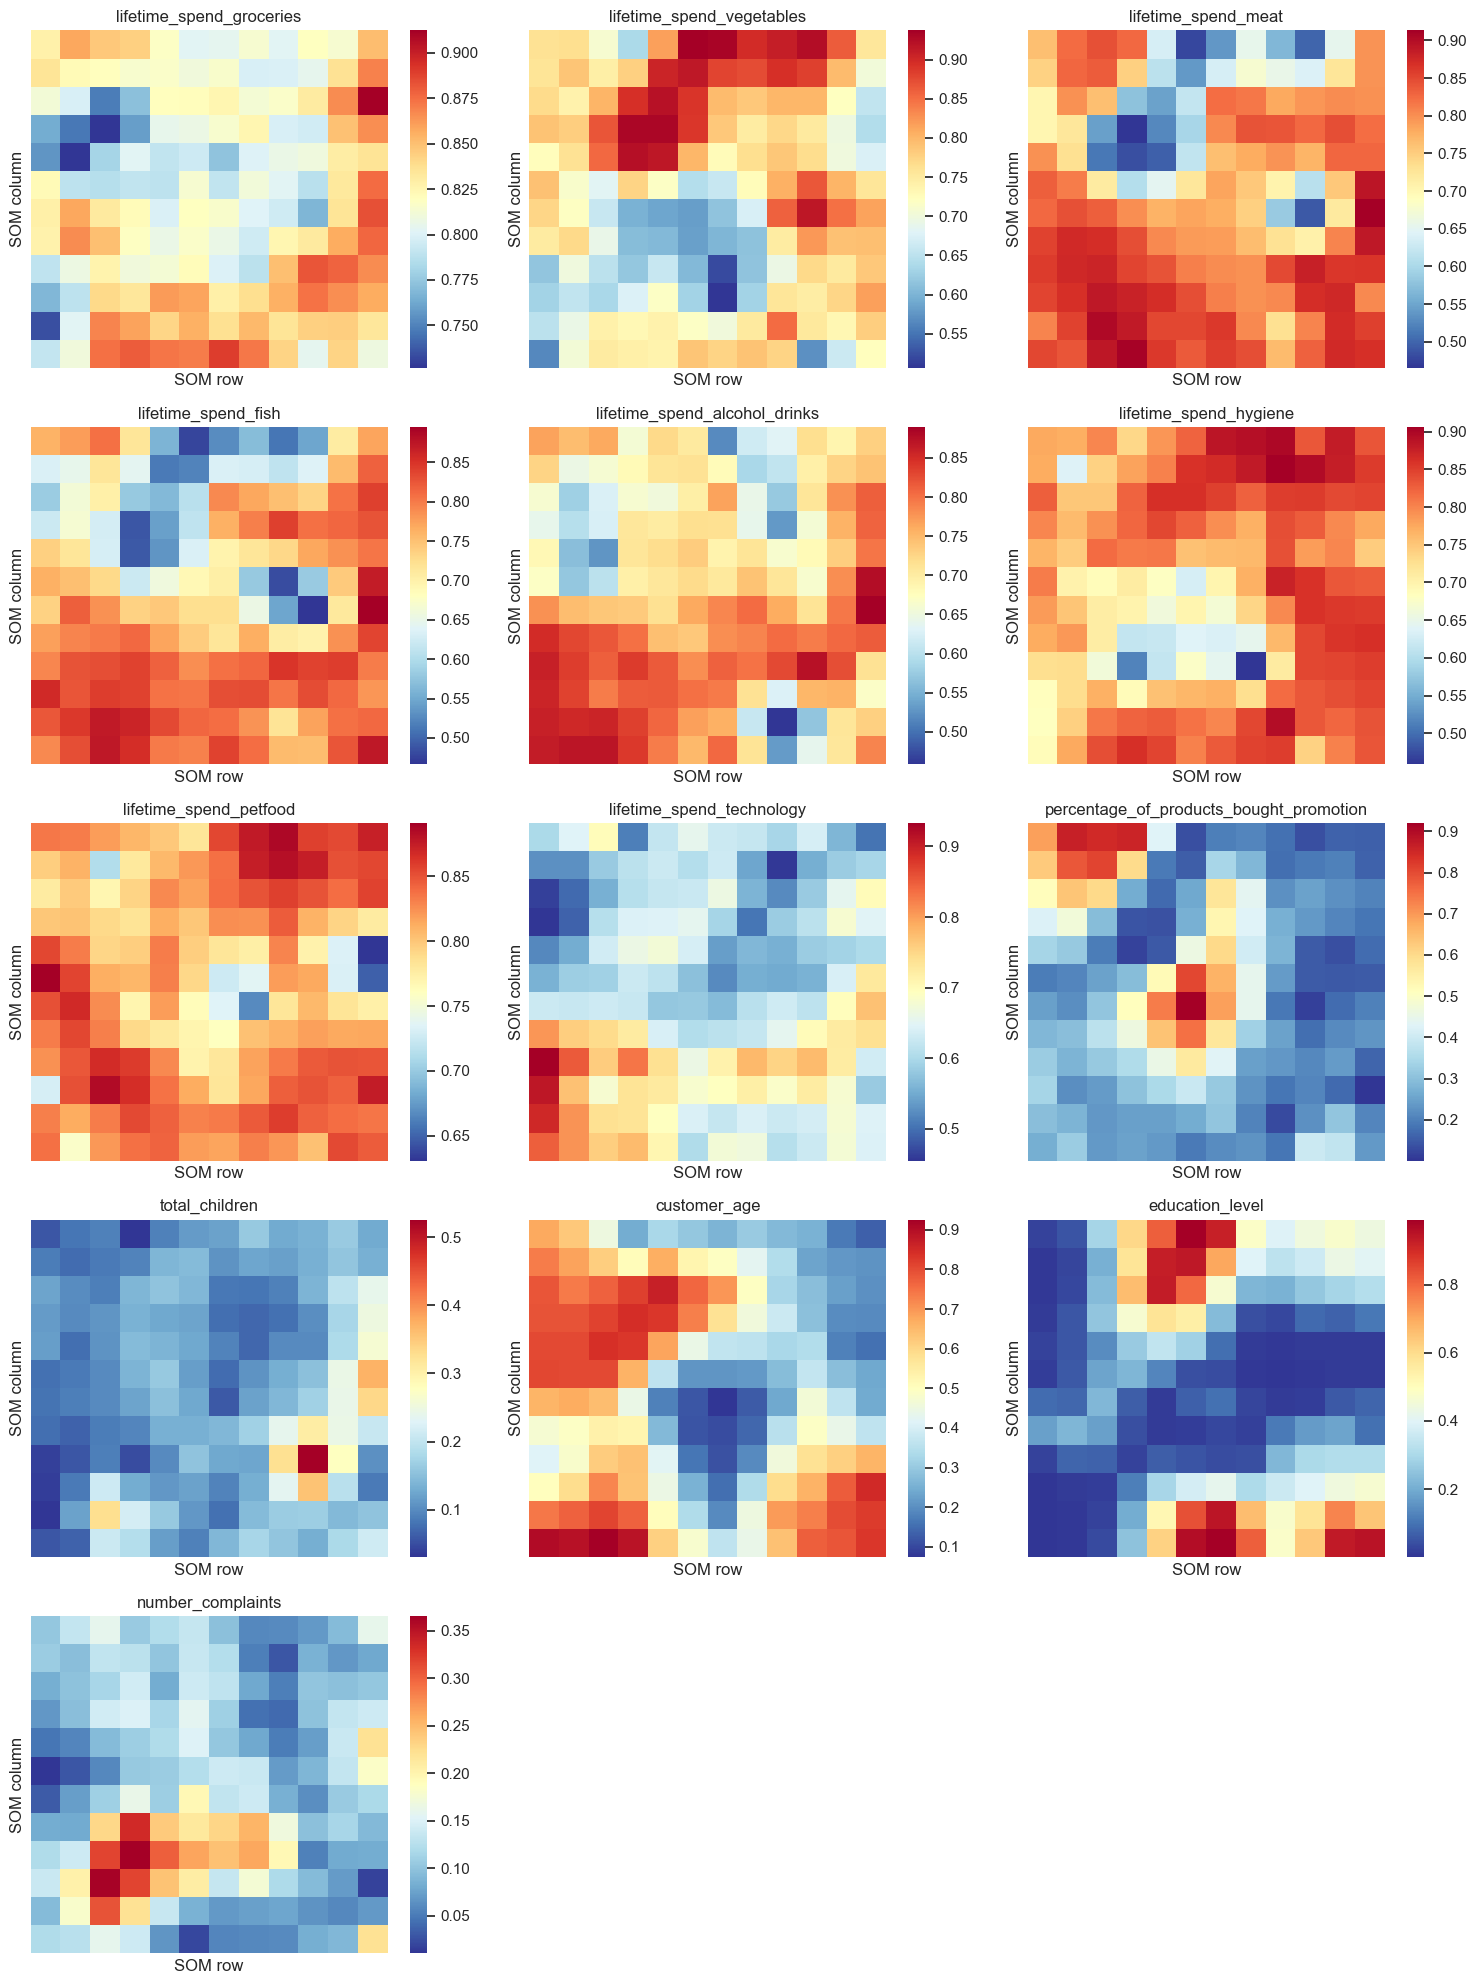

In [28]:
som_units = uc.assign_som_units(som_model, X_som)
regular["som_unit"] = som_units

som_counts = pd.Series(som_units).value_counts()
print("Active SOM units:", som_counts.shape[0], "out of", SOM_GRID[0] * SOM_GRID[1])
display(som_counts.rename("customers").sort_values(ascending=False).head(15).to_frame())
uc.plot_som_unit_counts(som_units, grid=SOM_GRID, title="SOM hit map", annot=False)

uc.plot_som_feature_maps(
    som_model,
    feature_names=som_cols,
    features=som_cols,
    n_cols=3,
)

### 7.5.1 — SOM interpretation

The SOM is interpreted as visual support for the final segmentation. It is useful when the same regions of the map repeatedly show high values for related variables, because that indicates coherent behavioural patterns in the customer space.

The main aspects to inspect are:

- vegetables and hygiene, which support the wellness-oriented interpretation;
- technology, which supports the technology-focused segment;
- promotion usage, which supports the promotion-driven segment;
- children-related variables, which support the family stock-up segment;
- complaints, which help identify more service-sensitive customers.

Since the SOM does not optimise the same objective as KMeans, it is not used to assign final labels. It is kept as an additional diagnostic to check whether the final segment names are consistent with visible behavioural regions.

### 8 — Ensemble / consensus clustering (robustness check)
<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
After comparing the individual clustering methods, a consensus KMeans procedure is used to measure stability. The same configuration is fitted several times with different random states; each customer receives the label that appears most consistently. High agreement between the single run and the consensus solution supports the final model as stable rather than accidental.
</div>


Single-run silhouette  : 0.2743


Consensus  silhouette  : 0.2741
Agreement single vs consensus (ARI): 0.9948
Mean stability: 0.924 | very stable (>=0.9): 76.8% | ambiguous (<0.6): 0.3%


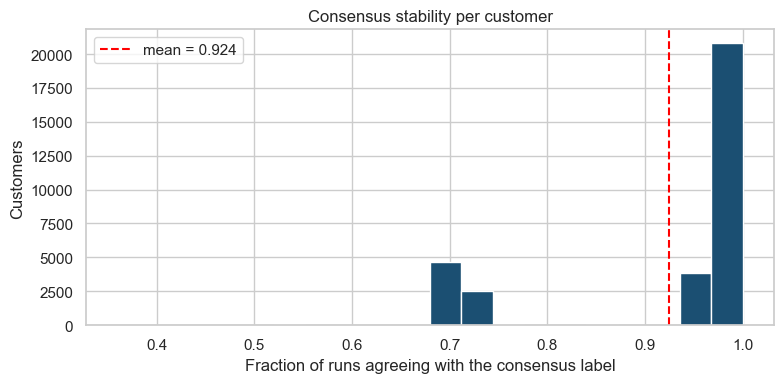

In [29]:
consensus_labels, stability = uc.consensus_kmeans(X, K, n_runs=25, random_state=0)
regular["cluster_stability"] = stability

from sklearn.metrics import silhouette_score, adjusted_rand_score
print("Single-run silhouette  :", round(silhouette_score(
    X, kmeans.labels_, sample_size=8000, random_state=0), 4))
print("Consensus  silhouette  :", round(silhouette_score(
    X, consensus_labels, sample_size=8000, random_state=0), 4))
print("Agreement single vs consensus (ARI):",
      round(adjusted_rand_score(kmeans.labels_, consensus_labels), 4))
print("Mean stability:", round(stability.mean(), 3),
      "| very stable (>=0.9):", f"{(stability>=0.9).mean()*100:.1f}%",
      "| ambiguous (<0.6):", f"{(stability<0.6).mean()*100:.1f}%")

uc.plot_stability(stability)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>9) Segment profiling</b></h2>
<p style="margin:6px 0 0 0;">Cluster interpretation is performed after fitting the model. The profiling tables compare each segment with the overall customer base using spend, demographic, engagement, location and complaint variables. This avoids naming clusters only from the distance variables and produces more distinctive business labels.</p>
</div>


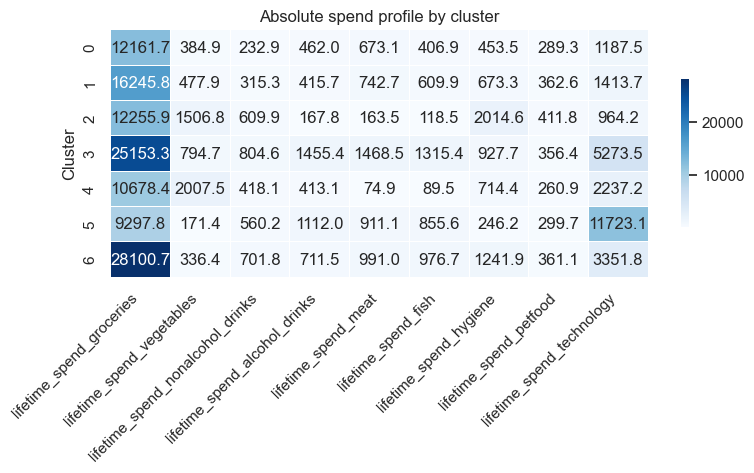

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_spend_technology
cluster,,,,,,,,,
0,12161.72,384.86,232.89,461.96,673.11,406.92,453.54,289.33,1187.54
1,16245.84,477.86,315.27,415.67,742.72,609.91,673.28,362.56,1413.67
2,12255.94,1506.77,609.94,167.85,163.49,118.48,2014.59,411.81,964.23
3,25153.28,794.67,804.61,1455.40,1468.50,1315.41,927.71,356.43,5273.52
4,10678.37,2007.50,418.15,413.12,74.94,89.48,714.36,260.90,2237.24
5,9297.81,171.38,560.21,1111.98,911.08,855.65,246.18,299.73,11723.08
6,28100.70,336.38,701.81,711.48,991.03,976.66,1241.93,361.11,3351.80
OVERALL,15925.51,729.54,457.41,607.75,711.43,595.22,818.06,333.85,3015.00


In [30]:
spend_cols = [c for c in regular.columns if c.startswith('lifetime_spend_')]
spend_profile = uc.profile_clusters(regular, 'cluster', spend_cols)
uc.plot_profile_heatmap(spend_profile, 'Absolute spend profile by cluster')
spend_profile


### 9.1 — Petfood signal check

Petfood spending is checked separately because one previous naming option considered a pet-oriented segment. A segment should only be named after petfood if the category is clearly distinctive, either in absolute spend or as a relevant share of its total basket.


In [31]:
if "lifetime_spend_petfood" in spend_profile.columns:
    pet_check = spend_profile.drop(index="OVERALL", errors="ignore").copy()
    pet_spend_cols = [c for c in pet_check.columns if c.startswith("lifetime_spend_")]
    pet_check["petfood_share_%"] = (
        pet_check["lifetime_spend_petfood"] / pet_check[pet_spend_cols].sum(axis=1) * 100
    )
    pet_check = pet_check[["lifetime_spend_petfood", "petfood_share_%"]].round(2)
    display(pet_check.sort_values("lifetime_spend_petfood", ascending=False))

    print("Highest absolute petfood cluster:", pet_check["lifetime_spend_petfood"].idxmax())
    print("Highest petfood share cluster:", pet_check["petfood_share_%"].idxmax())


,lifetime_spend_petfood,petfood_share_%
cluster,,
2,411.81,2.26
1,362.56,1.71
6,361.11,0.98
3,356.43,0.95
5,299.73,1.19
0,289.33,1.78
4,260.90,1.54


Highest absolute petfood cluster: 2
Highest petfood share cluster: 2


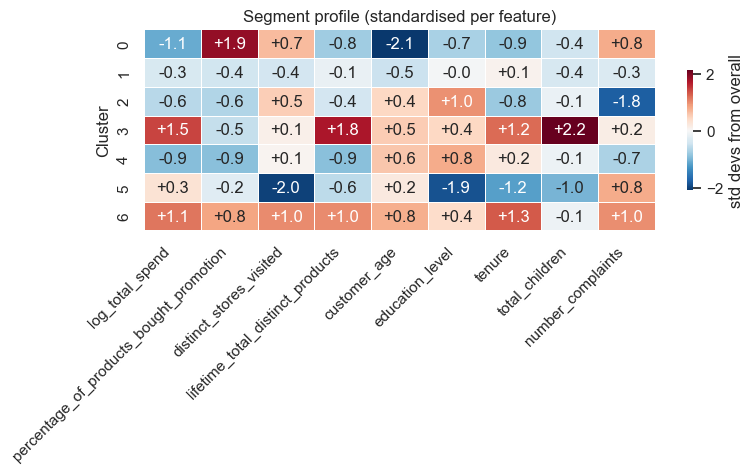

,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints
cluster,,,,,,,,,
0,-1.08,1.89,0.68,-0.76,-2.08,-0.70,-0.86,-0.43,0.79
1,-0.34,-0.42,-0.41,-0.15,-0.47,-0.04,0.10,-0.36,-0.31
2,-0.59,-0.64,0.52,-0.41,0.44,1.00,-0.80,-0.14,-1.78
3,1.46,-0.51,0.13,1.75,0.54,0.44,1.21,2.15,0.16
4,-0.91,-0.90,0.06,-0.89,0.58,0.80,0.21,-0.12,-0.67
5,0.32,-0.25,-2.01,-0.56,0.22,-1.88,-1.18,-1.00,0.79
6,1.15,0.84,1.03,1.02,0.77,0.39,1.31,-0.10,1.00


In [32]:
key_cols = [c for c in [
    "log_total_spend", "percentage_of_products_bought_promotion",
    "distinct_stores_visited", "lifetime_total_distinct_products",
    "customer_age", "education_level", "tenure", "total_children",
    "number_complaints",
] if c in regular.columns]

mixed_profile = uc.profile_clusters(regular, "cluster", key_cols)
uc.plot_profile_heatmap_z(mixed_profile,
                          title="Segment profile (standardised per feature)")

### 9.2 — Segment separation plots

The following plots summarise the same profiling logic in a more visual way. The scaled mean comparison highlights which clusters are highest or lowest on each variable, while the boxplots show whether the separation is concentrated around the median or driven mainly by extreme customers.


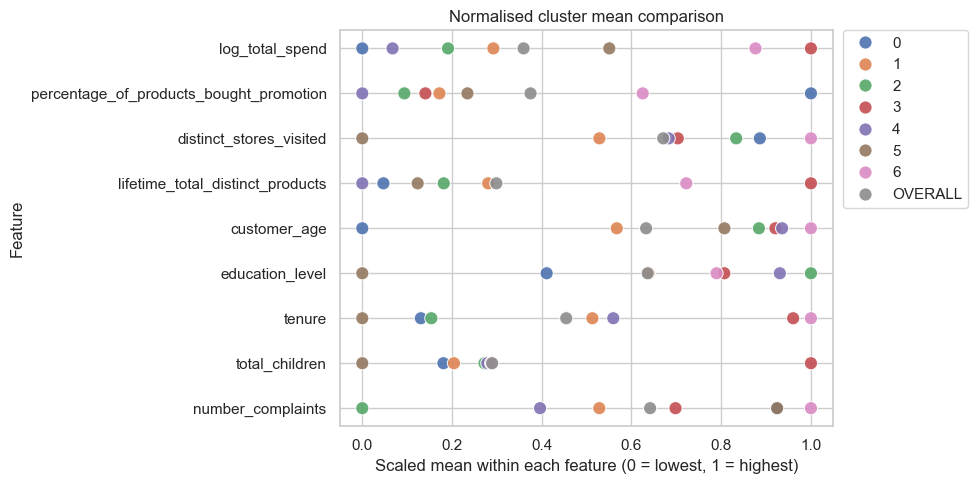

,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints
cluster,,,,,,,,,
0,0.00,1.00,0.89,0.05,0.00,0.41,0.13,0.18,0.92
1,0.29,0.17,0.53,0.28,0.57,0.64,0.51,0.20,0.53
2,0.19,0.09,0.83,0.18,0.88,1.00,0.15,0.27,0.00
3,1.00,0.14,0.70,1.00,0.92,0.81,0.96,1.00,0.70
4,0.07,0.00,0.68,0.00,0.94,0.93,0.56,0.28,0.40
5,0.55,0.23,0.00,0.12,0.81,0.00,0.00,0.00,0.92
6,0.88,0.62,1.00,0.72,1.00,0.79,1.00,0.29,1.00
OVERALL,0.36,0.38,0.67,0.30,0.63,0.64,0.45,0.29,0.64


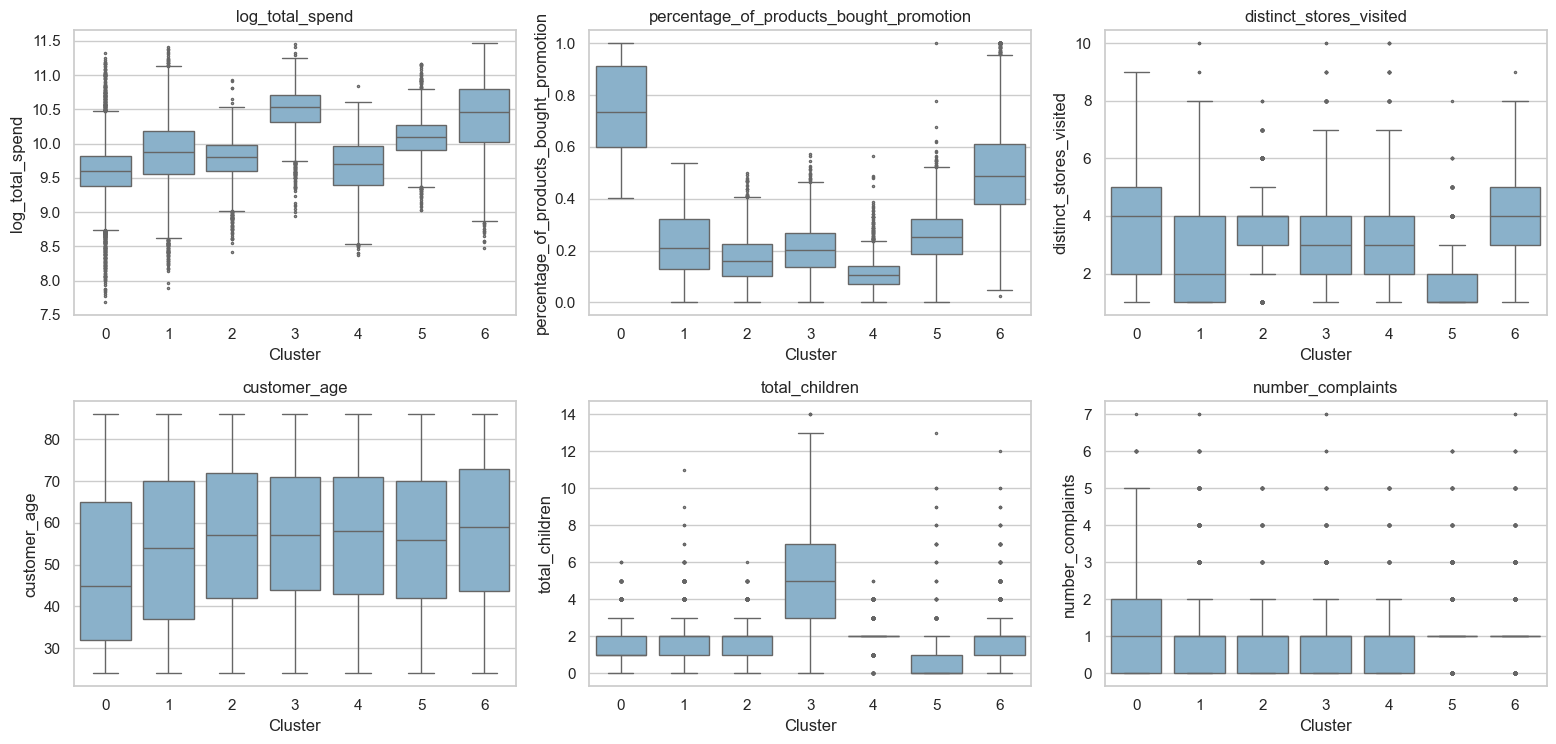

In [33]:
profile_plot_cols = [c for c in [
    "log_total_spend",
    "percentage_of_products_bought_promotion",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "customer_age",
    "education_level",
    "tenure",
    "total_children",
    "number_complaints",
] if c in regular.columns]

profile_for_plot = uc.profile_clusters(regular, "cluster", profile_plot_cols)
scaled_profile = uc.plot_cluster_mean_comparison(
    profile_for_plot,
    title="Normalised cluster mean comparison",
)
display(scaled_profile)

boxplot_cols = [c for c in [
    "log_total_spend",
    "percentage_of_products_bought_promotion",
    "distinct_stores_visited",
    "customer_age",
    "total_children",
    "number_complaints",
] if c in regular.columns]
uc.plot_boxplot_grid(regular, boxplot_cols, label_col="cluster")


### 9.3 — Complaint behaviour by segment

Complaint behaviour is reviewed separately because it can support the interpretation of segments with higher service sensitivity or dissatisfaction risk.


In [34]:
complaints_profile = uc.complaint_summary(
    regular,
    label_col="cluster",
    complaint_col="number_complaints",
    threshold=2,
)
display(complaints_profile)


,customers,avg_complaints,pct_complaints_ge_2,max_complaints
cluster,,,,
0,6648,1.06,31.4,7
1,8481,0.85,21.7,7
2,3273,0.57,3.1,5
3,3374,0.94,19.7,7
4,3714,0.78,7.7,5
5,3046,1.06,24.0,6
6,3520,1.10,20.1,7


### 9.4 — Geographic profiling

Geographic variables are used only after clustering, as profiling variables. They are not included in the clustering distance because location could dominate the segmentation and create geographic groups instead of behavioural customer segments.

The scatter plot provides a first visual check of whether any segment is spatially concentrated. Because most customers are located in a dense Lisbon-area rectangle, overlap is expected. The purpose of this section is therefore not to define clusters geographically, but to identify whether any segment has a noticeable location pattern that can support interpretation or business actions.


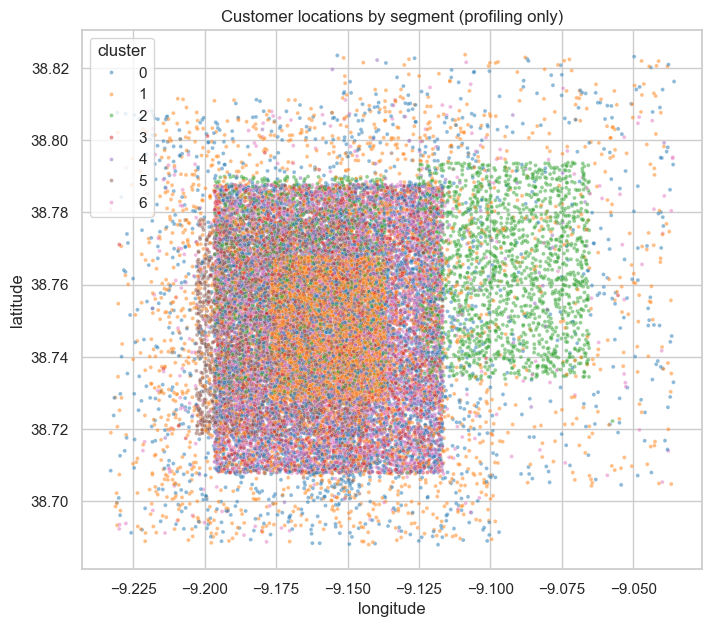

In [35]:
if {'latitude','longitude'}.issubset(regular.columns):
    plt.figure(figsize=(8, 7))
    sns.scatterplot(data=regular, x='longitude', y='latitude',
                    hue='cluster', palette='tab10', s=8, alpha=0.5, legend='full')
    plt.title('Customer locations by segment (profiling only)')
    plt.show()

,customers,mean_latitude,mean_longitude,median_latitude,median_longitude,latitude_std,longitude_std
cluster,,,,,,,
0,6648,38.74806,-9.15455,38.74769,-9.15656,0.02401,0.02747
1,8481,38.74864,-9.15529,38.74785,-9.15659,0.02162,0.02600
2,3273,38.76224,-9.12971,38.76210,-9.12370,0.01754,0.03961
3,3374,38.74820,-9.15719,38.74838,-9.15727,0.02337,0.02337
4,3714,38.74782,-9.15628,38.74746,-9.15645,0.02308,0.02402
5,3046,38.74826,-9.17193,38.74875,-9.17168,0.01774,0.01805
6,3520,38.74860,-9.15576,38.74780,-9.15623,0.02425,0.02658


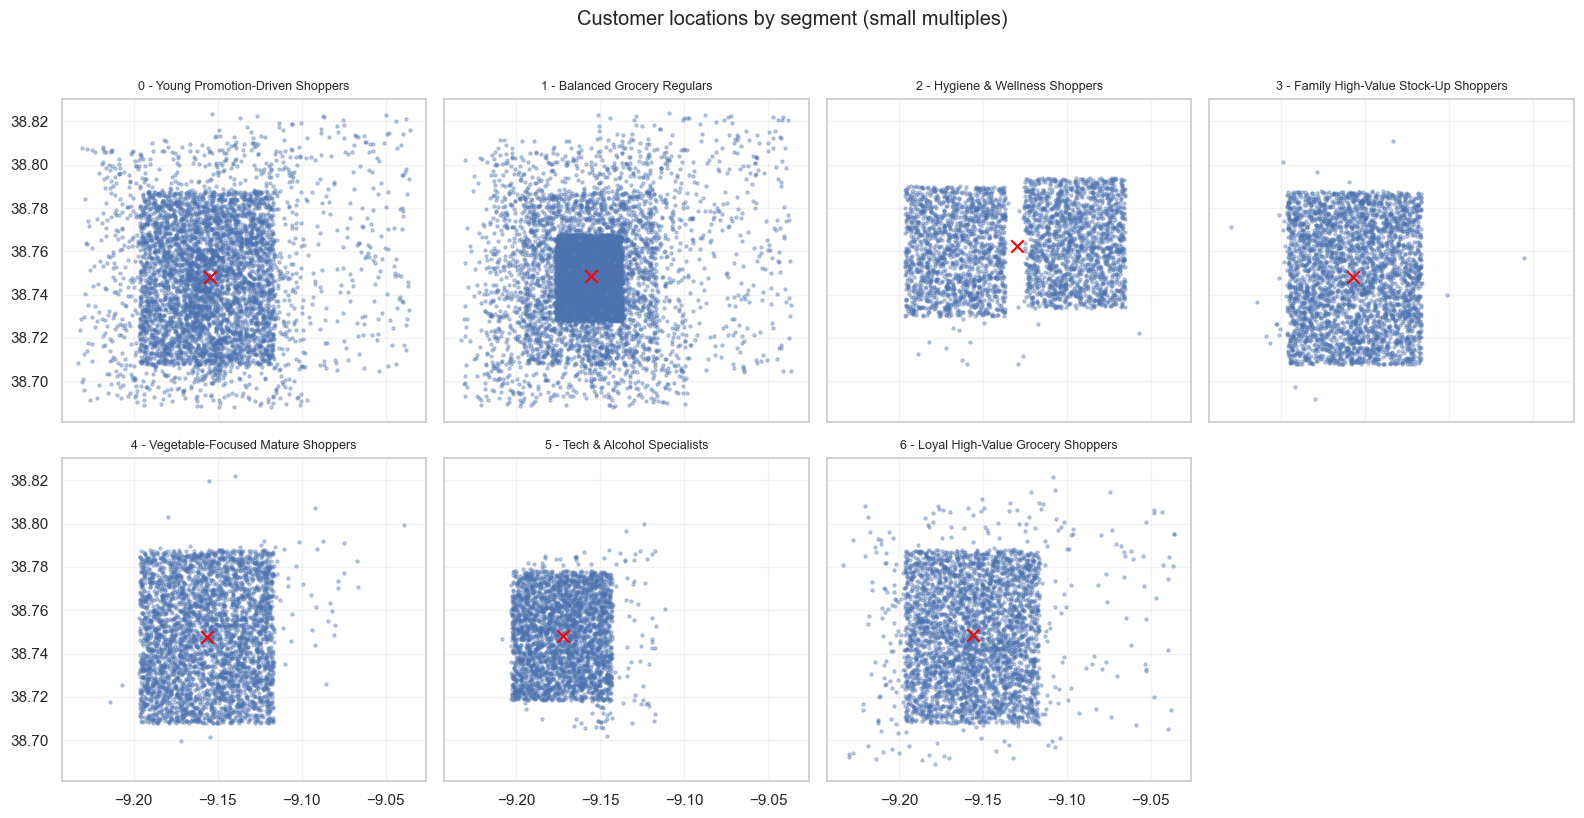

In [36]:
if {"latitude", "longitude"}.issubset(regular.columns):
    geo_profile = (
        regular
        .groupby("cluster")
        .agg(
            customers=("cluster", "size"),
            mean_latitude=("latitude", "mean"),
            mean_longitude=("longitude", "mean"),
            median_latitude=("latitude", "median"),
            median_longitude=("longitude", "median"),
            latitude_std=("latitude", "std"),
            longitude_std=("longitude", "std"),
        )
        .round(5)
    )
    display(geo_profile)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
    axes = axes.ravel()
    for ax, cluster_id in zip(axes, sorted(regular["cluster"].unique())):
        sub = regular[regular["cluster"] == cluster_id]
        ax.scatter(sub["longitude"], sub["latitude"], s=5, alpha=0.35)
        ax.scatter(
            sub["longitude"].mean(),
            sub["latitude"].mean(),
            s=80,
            color="red",
            marker="x",
            label="centroid",
        )
        name = cluster_names.get(cluster_id, f"Cluster {cluster_id}") if "cluster_names" in locals() else f"Cluster {cluster_id}"
        ax.set_title(f"{cluster_id} - {name}", fontsize=9)
        ax.grid(True, alpha=0.25)
    for ax in axes[len(sorted(regular["cluster"].unique())):]:
        ax.axis("off")
    fig.suptitle("Customer locations by segment (small multiples)", y=1.02)
    plt.tight_layout()
    plt.show()


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
<b>Geographic interpretation.</b><br><br>
The geographic plot should be interpreted cautiously. A strong overlap between colours means that the final clusters are mainly behavioural rather than geographic, which is desirable because latitude and longitude were intentionally excluded from the clustering distance. If one segment appears more concentrated in a specific area, this can be reported as a profiling insight, but it should not be treated as the main reason for the segment definition.
<br><br>
In practical terms, this analysis can support local marketing decisions, store-level planning or regional campaign targeting. However, the final segment names remain based on spending, promotion behaviour, demographic profile and customer stability rather than location alone.
</div>


### 9.5 — Cluster name mapping

The final labels are assigned after reviewing the spend, behavioural and demographic profiles. These names are descriptive business labels and can be revised if the model configuration changes.


In [37]:
if set(regular["cluster"].unique()) != set(cluster_names):
    print("Cluster-name mapping does not match the current cluster labels. Update CLUSTER_NAMES in utils_cluster_characterization.py.")
else:
    regular["cluster_name"] = regular["cluster"].map(cluster_names)
    display(regular[["cluster", "cluster_name"]].drop_duplicates().sort_values("cluster"))

,cluster,cluster_name
customer_id,,
3,0,Young Promotion-Driven Shoppers
5,1,Balanced Grocery Regulars
4,2,Hygiene & Wellness Shoppers
10,3,Family High-Value Stock-Up Shoppers
9,4,Vegetable-Focused Mature Shoppers
7,5,Tech & Alcohol Specialists
20,6,Loyal High-Value Grocery Shoppers


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin:0;"><b>10) Re-attach outliers and export</b></h2>
<p style="margin:6px 0 0 0;">Outliers are not used to fit the KMeans centroids, because their extreme values could distort the segment centres. After the model is fitted on regular customers, the held-aside outliers are projected through the same feature pipeline and assigned to the nearest centroid. This preserves full customer coverage while keeping the learned segments robust.</p>
</div>


In [38]:
X_out = uc.apply_feature_pipeline(outliers, distance_cols, LOGABS, scaler, fit=False)
outlier_labels = kmeans.predict(X_out)
print('Outliers assigned:', len(outlier_labels))

segments = uc.build_full_assignment(regular, kmeans.labels_, outliers, outlier_labels,
                                    label_col='cluster', id_name='customer_id')
assert segments['customer_id'].nunique() == len(regular) + len(outliers), 'Missing customers!'
print('Customers in final file:', segments['customer_id'].nunique())
print(segments['cluster'].value_counts().sort_index())

if "cluster_names" in locals() and set(segments["cluster"].unique()).issubset(cluster_names):
    segments["cluster_name"] = segments["cluster"].map(cluster_names)


Outliers assigned: 982
Customers in final file: 33038
cluster
0    6762
1    8561
2    3332
3    3754
4    3739
5    3231
6    3659
Name: count, dtype: int64


In [39]:
segments.to_csv(f'{DATA_DIR}/customer_segments.csv', index=False)
uc.cluster_sizes(regular, 'cluster').to_csv(f'{DATA_DIR}/segment_summary.csv')
spend_profile.to_csv(f'{DATA_DIR}/segment_spend_profile.csv')
if 'complaints_profile' in locals():
    complaints_profile.to_csv(f'{DATA_DIR}/segment_complaints_profile.csv')
if 'regular' in locals() and 'cluster_name' in regular.columns:
    regular[['cluster', 'cluster_name']].drop_duplicates().sort_values('cluster').to_csv(
        f'{DATA_DIR}/segment_name_mapping.csv', index=False
    )
print('Saved customer_segments.csv (+ summary, spend profile, complaints profile and name mapping) to', DATA_DIR)

Saved customer_segments.csv (+ summary, spend profile, complaints profile and name mapping) to /Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/datasets


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
<code>customer_segments.csv</code> is the required deliverable, containing one final segment assignment per customer. The additional exports support interpretation: <code>segment_summary.csv</code> gives segment sizes, <code>segment_spend_profile.csv</code> supports spend-based profiling, <code>segment_complaints_profile.csv</code> highlights service sensitivity, and <code>segment_name_mapping.csv</code> documents the final business labels.
</div>


## 11) Final modelling conclusion

The final segmentation is based on KMeans with `k = 7`, using the `spend + promo no groceries` feature set and MinMax scaling. This solution was selected because it provides a strong balance between quantitative validation and business interpretability.

The average silhouette score is moderate, which is expected in behavioural customer data where customers often lie on continuous consumption gradients. The consensus validation is very strong: the single KMeans solution and the consensus labels are almost identical, with very high agreement and a very small proportion of ambiguous customers. This indicates that the solution is stable and not driven by a particular random initialization.

Alternative methods were used as benchmarks. Hierarchical clustering confirmed part of the broad structure but produced less favourable macro-cluster separation. DBSCAN was not retained as the final model because its best configurations either labelled too many customers as noise or collapsed the data into too few dense groups. SOM was retained as an exploratory visualization tool, helping to inspect behavioural regions through hit maps, U-Matrix and feature maps, but not as the final assignment method.

The final names are assigned from the full profiling view rather than from the distance variables alone. The petfood check showed that petfood is not dominant enough to justify a pet-oriented segment name. The final solution therefore favours clearer segment identities: promotion-driven, balanced grocery, hygiene/wellness, family stock-up, vegetable-focused, technology/alcohol and high-value grocery customers.


In [40]:
abs_cols = [c for c in regular.columns if c.startswith("lifetime_spend_")]
abs_profile = uc.profile_clusters(regular, "cluster", abs_cols)

profile_cols = [
    c for c in [
        "log_total_spend",
        "percentage_of_products_bought_promotion",
        "distinct_stores_visited",
        "lifetime_total_distinct_products",
        "customer_age",
        "education_level",
        "tenure",
        "total_children",
        "number_complaints",
        "customer_loyalty_flag",
        "is_male",
        "latitude",
        "longitude",
    ]
    if c in regular.columns
]
behaviour_profile = uc.profile_clusters(regular, "cluster", profile_cols)

display(abs_profile)
display(behaviour_profile)

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_spend_technology
cluster,,,,,,,,,
0,12161.72,384.86,232.89,461.96,673.11,406.92,453.54,289.33,1187.54
1,16245.84,477.86,315.27,415.67,742.72,609.91,673.28,362.56,1413.67
2,12255.94,1506.77,609.94,167.85,163.49,118.48,2014.59,411.81,964.23
3,25153.28,794.67,804.61,1455.40,1468.50,1315.41,927.71,356.43,5273.52
4,10678.37,2007.50,418.15,413.12,74.94,89.48,714.36,260.90,2237.24
5,9297.81,171.38,560.21,1111.98,911.08,855.65,246.18,299.73,11723.08
6,28100.70,336.38,701.81,711.48,991.03,976.66,1241.93,361.11,3351.80
OVERALL,15925.51,729.54,457.41,607.75,711.43,595.22,818.06,333.85,3015.00


,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints,customer_loyalty_flag,is_male,latitude,longitude
cluster,,,,,,,,,,,,,
0,9.60,0.75,3.70,93.70,49.05,13.86,9.62,1.46,1.06,0.59,0.49,38.75,-9.15
1,9.86,0.22,2.82,142.54,53.99,14.78,11.26,1.57,0.85,0.58,0.50,38.75,-9.16
2,9.77,0.17,3.57,121.81,56.75,16.24,9.72,1.89,0.57,0.59,0.50,38.76,-9.13
3,10.49,0.20,3.25,292.96,57.07,15.46,13.18,5.31,0.94,0.69,0.52,38.75,-9.16
4,9.66,0.11,3.20,83.86,57.20,15.96,11.46,1.92,0.78,0.58,0.51,38.75,-9.16
5,10.09,0.26,1.52,109.67,56.08,12.20,9.06,0.61,1.06,0.49,0.47,38.75,-9.17
6,10.38,0.51,3.98,234.85,57.76,15.39,13.35,1.96,1.10,0.76,0.50,38.75,-9.16
OVERALL,9.92,0.35,3.17,146.34,54.56,14.77,11.01,1.97,0.91,0.61,0.50,38.75,-9.15


In [41]:
key_cols = [
    "percentage_of_products_bought_promotion",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "customer_age",
    "total_children",
    "tenure",
    "number_complaints",
]

key_cols = [c for c in key_cols if c in regular.columns]

general_profile = uc.profile_clusters(regular, "cluster", key_cols)